# TSMC · In-depth market EDA
### Daily • weekly • monthly • yearly

Investigate trends, calendar seasonality, trading-day coverage, holidays, unusual observations, correlations and serial dependence. TSM is treated as the **US-listed instrument using the NYSE calendar**, not the Taiwan exchange calendar.

Default scope: the full local master dataset. **Full-history EDA must not guide model selection while the existing test set is described as untouched.** Set `ANALYSIS_END` to a training cutoff for modelling decisions. Decomposition and full-sample anomaly thresholds are retrospective descriptions, not trading signals. No rows are silently removed or filled; anomaly flags mean inspect, not delete.

## 1 · Environment
Dependencies: `numpy pandas scipy matplotlib statsmodels pandas-market-calendars`.
If missing, run `%pip install numpy pandas scipy matplotlib statsmodels pandas-market-calendars` in the notebook environment and restart the kernel. No automatic installation or market-data download. Plots use Matplotlib; no GPU or deep-learning libraries.

In [1]:
import os
for name in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(name, "1")
import json
import warnings
import hashlib
from pathlib import Path
from importlib.metadata import version
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.multitest import multipletests
import pandas_market_calendars as mcal
try:
    from IPython.display import display
except ImportError:
    display = print

plt.rcParams.update({"figure.figsize": (12,4), "figure.dpi":100,
    "axes.spines.top":False, "axes.spines.right":False, "axes.grid":True, "grid.alpha":.2})
pd.set_option("display.max_columns", 18)
pd.set_option("display.max_rows", 25)
VERSIONS = {p:version(p) for p in ["numpy","pandas","scipy","matplotlib","statsmodels","pandas-market-calendars"]}
print(VERSIONS)
DATA_PATH = next((p / "Data/TSMC_Master_Features_15Y.csv" for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "Data/TSMC_Master_Features_15Y.csv").is_file()), None)
if DATA_PATH is None: raise FileNotFoundError("Run inside the project or set DATA_PATH explicitly.")
ANALYSIS_END = None  # Use '2022-03-07' for training-origin-only EDA.
CALENDAR_NAME = "NYSE"
EXPORT_TABLES = False
OUTPUT_DIR = DATA_PATH.parent.parent / "results/eda"
TABLES = {}

def show_table(name, frame, rows=15):
    TABLES[name] = frame.copy()
    print(f"{name}: {len(frame):,} rows; complete table retained in TABLES")
    display(frame.head(rows))

def heatmap(frame, title, annotate=False):
    values = frame.to_numpy(dtype=float)
    finite = values[np.isfinite(values)]
    if not len(finite): print("No finite values:", title); return
    lim = max(float(np.abs(finite).max()), 1e-12)
    fig, ax = plt.subplots(figsize=(max(8,.6*len(frame.columns)), max(4,.3*len(frame))))
    image = ax.imshow(np.ma.masked_invalid(values), aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim)
    ax.set_xticks(range(len(frame.columns)), labels=frame.columns.astype(str), rotation=75)
    ax.set_yticks(range(len(frame)), labels=frame.index.astype(str))
    ax.set_title(title); ax.grid(False)
    if annotate:
        for i,j in np.ndindex(values.shape):
            if np.isfinite(values[i,j]): ax.text(j,i,f"{values[i,j]:.1f}",ha="center",va="center",fontsize=7)
    fig.colorbar(image, ax=ax, shrink=.8)
    plt.tight_layout(); plt.show()

{'numpy': '2.5.3', 'pandas': '3.0.6', 'scipy': '1.18.1', 'matplotlib': '3.11.2', 'statsmodels': '0.15.0', 'pandas-market-calendars': '5.4.0'}


## 2 · Data inventory and quality
The CSV was prepared from the project's Yahoo dataset in `features.ipynb`; its vendor provenance is not independently authenticated here. Initial lag/rolling-feature missing values are expected warm-up. Internal missing values, duplicate dates, impossible OHLC ranges and invalid volumes are separate quality issues. Repeated closes can be legitimate.

In [2]:
raw = pd.read_csv(DATA_PATH)
raw["Date"] = pd.to_datetime(raw.Date, errors="raise").dt.normalize()
print("Original shape:",raw.shape,"| originally sorted:",raw.Date.is_monotonic_increasing)
duplicates = raw.loc[raw.Date.duplicated(keep=False)].sort_values("Date")
show_table("duplicate_dates",duplicates)
if len(duplicates): raise ValueError("Resolve duplicate dates before aggregation.")
df = raw.sort_values("Date").set_index("Date")
if ANALYSIS_END is not None: df = df.loc[:ANALYSIS_END].copy()
if len(df)<60 or df.index.hasnans: raise ValueError("Need at least 60 dated observations.")
df = df.apply(pd.to_numeric,errors="raise")
base = ["Open","High","Low","Close","Adj Close","Volume"]
if not np.isfinite(df[base].to_numpy()).all(): raise ValueError("Missing/infinite market values require investigation.")
if (df[base[:-1]]<=0).any().any(): raise ValueError("Nonpositive prices prevent logarithmic analysis.")
inventory = pd.DataFrame({"Missing":df.isna().sum(),"Missing_pct":df.isna().mean()*100,
    "Unique":df.nunique(),"Dtype":df.dtypes.astype(str)})
inventory["Internal_missing"] = [int(df[c].loc[df[c].first_valid_index():].isna().sum())
    if df[c].notna().any() else len(df) for c in df]
show_table("feature_inventory",inventory,40)
quality = pd.DataFrame(index=df.index)
quality["OHLC_invalid"] = ((df.High+1e-6<df[["Open","Low","Close"]].max(axis=1)) |
    (df.Low-1e-6>df[["Open","High","Close"]].min(axis=1)))
quality["Negative_volume"] = df.Volume<0
quality["Zero_volume"] = df.Volume==0
quality["Unchanged_close"] = df.Close.diff().eq(0)
quality["Identical_OHLCV"] = df[base].eq(df[base].shift()).all(axis=1)
show_table("quality_flag_counts",quality.sum().to_frame("Count"))
show_table("quality_flagged_dates",df[base].join(quality).loc[quality.any(axis=1)])
show_table("descriptive_statistics",df.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T,40)
print("Analysed dates:",df.index.min().date(),"to",df.index.max().date(),"| rows:",len(df))

Original shape: (3771, 38) | originally sorted: True
duplicate_dates: 0 rows; complete table retained in TABLES
feature_inventory: 37 rows; complete table retained in TABLES
quality_flag_counts: 5 rows; complete table retained in TABLES
quality_flagged_dates: 38 rows; complete table retained in TABLES
descriptive_statistics: 37 rows; complete table retained in TABLES
Analysed dates: 2011-09-12 to 2026-09-10 | rows: 3771


,Date,Open,High,Low,Close,Adj Close,Volume,Log_Close,Return_1D,Log_Return_1D,High_Low_Range,Open_Close_Change,Close_Lag_1,Close_Lag_2,Close_Lag_3,Close_Lag_5,Close_Lag_10,Close_Lag_20,Return_Lag_1,Return_Lag_2,Return_Lag_3,Return_Lag_5,Return_Lag_10,Return_Lag_20,SMA_5,SMA_10,SMA_20,SMA_50,Volatility_5,Volatility_10,Volatility_20,Momentum_5D,Momentum_10D,Momentum_20D,Day_of_Week,Month,Quarter,Year


,Missing,Missing_pct,Unique,Dtype,Internal_missing
Open,0,0.000000,3017,float64,0
High,0,0.000000,3081,float64,0
Low,0,0.000000,3042,float64,0
Close,0,0.000000,3045,float64,0
Adj Close,0,0.000000,3357,float64,0
Volume,0,0.000000,3708,int64,0
Log_Close,0,0.000000,3045,float64,0
Return_1D,1,0.026518,3721,float64,0
Log_Return_1D,1,0.026518,3721,float64,0
High_Low_Range,0,0.000000,3761,float64,0


,Count
OHLC_invalid,0
Negative_volume,0
Zero_volume,0
Unchanged_close,38
Identical_OHLCV,0


,Open,High,Low,Close,Adj Close,Volume,OHLC_invalid,Negative_volume,Zero_volume,Unchanged_close,Identical_OHLCV
Date,,,,,,,,,,,
2011-11-22,12.560000,12.640000,12.480000,12.560000,8.566380,16107200,False,False,False,True,False
2012-04-16,15.260000,15.330000,15.040000,15.100000,10.298752,6344600,False,False,False,True,False
2012-05-11,15.200000,15.530000,15.200000,15.390000,10.496541,7900500,False,False,False,True,False
2012-07-09,13.420000,13.540000,13.380000,13.500000,9.539114,10952700,False,False,False,True,False
2012-09-21,15.010000,15.040000,14.800000,14.800000,10.457697,9381100,False,False,False,True,False
2013-01-09,17.760000,17.930000,17.400000,17.540001,12.393785,12977400,False,False,False,True,False
2013-03-01,18.170000,18.350000,18.070000,18.250000,12.895472,8703200,False,False,False,True,False
2013-05-09,20.120001,20.299999,20.100000,20.209999,14.280411,8912600,False,False,False,True,False
2013-07-10,17.969999,18.110001,17.809999,17.840000,12.957360,8103100,False,False,False,True,False


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Open,3771.0,8.378650e+01,9.131102e+01,1.126000e+01,1.245800e+01,1.445000e+01,2.259000e+01,4.240000e+01,1.100000e+02,3.000050e+02,4.243770e+02,4.760900e+02
High,3771.0,8.478734e+01,9.260955e+01,1.164000e+01,1.260800e+01,1.457000e+01,2.283000e+01,4.266000e+01,1.114300e+02,3.043900e+02,4.291650e+02,4.790000e+02
Low,3771.0,8.267755e+01,8.978835e+01,1.126000e+01,1.234500e+01,1.433500e+01,2.239500e+01,4.210000e+01,1.087050e+02,2.966850e+02,4.168530e+02,4.651700e+02
Close,3771.0,8.374172e+01,9.121558e+01,1.131000e+01,1.248000e+01,1.444500e+01,2.265000e+01,4.242000e+01,1.101500e+02,3.001550e+02,4.217240e+02,4.775700e+02
Adj Close,3771.0,7.841233e+01,9.222475e+01,7.713831e+00,8.511815e+00,1.008732e+01,1.709528e+01,3.580878e+01,1.019046e+02,2.980607e+02,4.216287e+02,4.775700e+02
Volume,3771.0,1.049479e+07,5.525661e+06,1.499700e+06,3.138230e+06,4.465750e+06,6.962700e+06,9.440200e+06,1.256860e+07,1.993090e+07,2.970877e+07,6.866750e+07
Log_Close,3771.0,3.959701e+00,9.458391e-01,2.425687e+00,2.524127e+00,2.670348e+00,3.120160e+00,3.747620e+00,4.701843e+00,5.704299e+00,6.044351e+00,6.168711e+00
Return_1D,3770.0,1.151394e-03,2.010294e-02,-1.403408e-01,-5.037880e-02,-3.007870e-02,-9.616105e-03,8.229253e-04,1.137309e-02,3.375890e-02,5.586305e-02,1.265223e-01
Log_Return_1D,3770.0,9.494162e-04,2.006632e-02,-1.512192e-01,-5.169211e-02,-3.054035e-02,-9.662639e-03,8.225869e-04,1.130891e-02,3.320158e-02,5.435842e-02,1.191353e-01
High_Low_Range,3771.0,2.060090e-02,1.179237e-02,4.506297e-03,6.455837e-03,8.334662e-03,1.295961e-02,1.782021e-02,2.511009e-02,4.202829e-02,6.074244e-02,1.572942e-01


## 3 · Sessions, holidays, early closes and missing records
Audit every calendar date **inside the observed span**. Weekends are separate from weekday exchange closures. Early closes remain trading sessions. Holiday names come from the calendar's regular-holiday definitions; other closed weekdays are exceptional closures. These are versioned calendar classifications, not independently sourced explanations of historical events.

Year/month/week counts cover only the observed window. `Partial_boundary_period` identifies incomplete first/last periods: their counts are not full-year or full-month totals. Calendar closure counts must not be inferred merely from absent CSV rows.

calendar_totals: 9 rows; complete table retained in TABLES
calendar_Weekly: 783 rows; complete table retained in TABLES
calendar_Monthly: 181 rows; complete table retained in TABLES
calendar_Yearly: 16 rows; complete table retained in TABLES
closure_dates: 143 rows; complete table retained in TABLES
missing_expected_sessions: 0 rows; complete table retained in TABLES
unexpected_records: 0 rows; complete table retained in TABLES
early_close_dates: 33 rows; complete table retained in TABLES


,Count
Observed,3771
Expected_session,3771
Weekend,1564
Weekday_closure,143
Regular_holiday,139
Exceptional_closure,4
Early_close,33
Missing_session,0
Unexpected_record,0


,Observed,Expected_session,Weekend,Weekday_closure,Regular_holiday,Exceptional_closure,Early_close,Missing_session,Unexpected_record,Calendar_days_covered,Coverage_pct,Partial_boundary_period
Date,,,,,,,,,,,,
2011-09-12/2011-09-18,5,5,2,0,0,0,0,0,0,7,100.0,False
2011-09-19/2011-09-25,5,5,2,0,0,0,0,0,0,7,100.0,False
2011-09-26/2011-10-02,5,5,2,0,0,0,0,0,0,7,100.0,False
2011-10-03/2011-10-09,5,5,2,0,0,0,0,0,0,7,100.0,False
2011-10-10/2011-10-16,5,5,2,0,0,0,0,0,0,7,100.0,False
2011-10-17/2011-10-23,5,5,2,0,0,0,0,0,0,7,100.0,False
2011-10-24/2011-10-30,5,5,2,0,0,0,0,0,0,7,100.0,False
2011-10-31/2011-11-06,5,5,2,0,0,0,0,0,0,7,100.0,False
2011-11-07/2011-11-13,5,5,2,0,0,0,0,0,0,7,100.0,False


,Observed,Expected_session,Weekend,Weekday_closure,Regular_holiday,Exceptional_closure,Early_close,Missing_session,Unexpected_record,Calendar_days_covered,Coverage_pct,Partial_boundary_period
Date,,,,,,,,,,,,
2011-09,15,15,4,0,0,0,0,0,0,19,100.0,True
2011-10,21,21,10,0,0,0,0,0,0,31,100.0,False
2011-11,21,21,8,1,1,0,1,0,0,30,100.0,False
2011-12,21,21,9,1,1,0,0,0,0,31,100.0,False
2012-01,20,20,9,2,2,0,0,0,0,31,100.0,False
2012-02,20,20,8,1,1,0,0,0,0,29,100.0,False
2012-03,22,22,9,0,0,0,0,0,0,31,100.0,False
2012-04,20,20,9,1,1,0,0,0,0,30,100.0,False
2012-05,22,22,8,1,1,0,0,0,0,31,100.0,False


,Observed,Expected_session,Weekend,Weekday_closure,Regular_holiday,Exceptional_closure,Early_close,Missing_session,Unexpected_record,Calendar_days_covered,Coverage_pct,Partial_boundary_period
Date,,,,,,,,,,,,
2011,78,78,31,2,2,0,1,0,0,111,100.0,True
2012,250,250,105,11,9,2,3,0,0,366,100.0,False
2013,252,252,104,9,9,0,3,0,0,365,100.0,False
2014,252,252,104,9,9,0,3,0,0,365,100.0,False
2015,252,252,104,9,9,0,2,0,0,365,100.0,False
2016,252,252,105,9,9,0,1,0,0,366,100.0,False
2017,251,251,105,9,9,0,2,0,0,365,100.0,False
2018,251,251,104,10,9,1,3,0,0,365,100.0,False
2019,252,252,104,9,9,0,3,0,0,365,100.0,False


,Holiday_name,Regular_holiday,Exceptional_closure
Date,,,
2011-11-24,Thanksgiving,True,False
2011-12-26,Christmas,True,False
2012-01-02,New Years Day,True,False
2012-01-16,Dr. Martin Luther King Jr. Day,True,False
2012-02-20,Presidents Day,True,False
2012-04-06,Good Friday 1908+,True,False
2012-05-28,Memorial Day,True,False
2012-07-04,July 4th,True,False
2012-09-03,Labor Day,True,False


,Observed,Expected_session,Weekend,Weekday_closure,Missing_session,Unexpected_record,Holiday_name,Regular_holiday,Exceptional_closure,Early_close
Date,,,,,,,,,,


,Observed,Expected_session,Weekend,Weekday_closure,Missing_session,Unexpected_record,Holiday_name,Regular_holiday,Exceptional_closure,Early_close
Date,,,,,,,,,,


,market_open,market_close
2011-11-25,2011-11-25 14:30:00+00:00,2011-11-25 18:00:00+00:00
2012-07-03,2012-07-03 13:30:00+00:00,2012-07-03 17:00:00+00:00
2012-11-23,2012-11-23 14:30:00+00:00,2012-11-23 18:00:00+00:00
2012-12-24,2012-12-24 14:30:00+00:00,2012-12-24 18:00:00+00:00
2013-07-03,2013-07-03 13:30:00+00:00,2013-07-03 17:00:00+00:00
2013-11-29,2013-11-29 14:30:00+00:00,2013-11-29 18:00:00+00:00
2013-12-24,2013-12-24 14:30:00+00:00,2013-12-24 18:00:00+00:00
2014-07-03,2014-07-03 13:30:00+00:00,2014-07-03 17:00:00+00:00
2014-11-28,2014-11-28 14:30:00+00:00,2014-11-28 18:00:00+00:00
2014-12-24,2014-12-24 14:30:00+00:00,2014-12-24 18:00:00+00:00


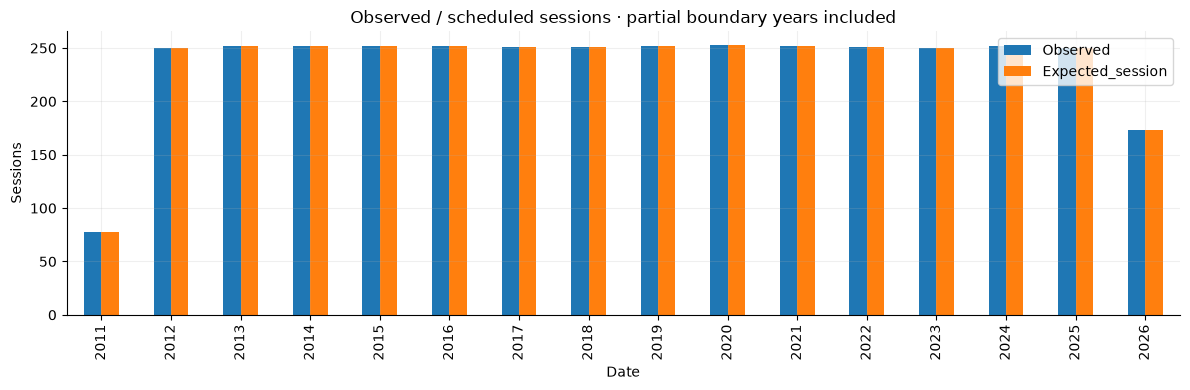

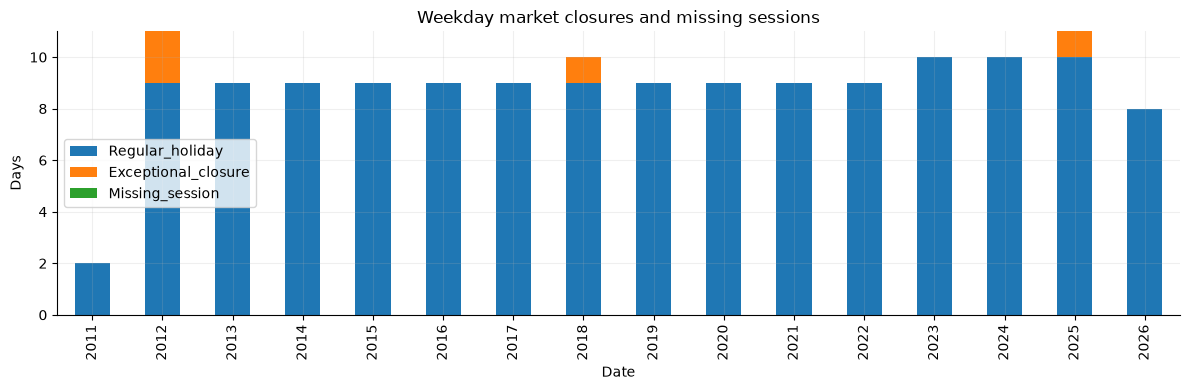

In [3]:
start,end = df.index.min(),df.index.max()
exchange = mcal.get_calendar(CALENDAR_NAME)
schedule = exchange.schedule(start_date=start,end_date=end)
sessions = pd.DatetimeIndex(schedule.index).tz_localize(None).normalize()
calendar = pd.DataFrame(index=pd.date_range(start,end,freq="D"))
calendar.index.name="Date"
calendar["Observed"] = calendar.index.isin(df.index)
calendar["Expected_session"] = calendar.index.isin(sessions)
calendar["Weekend"] = calendar.index.dayofweek>=5
calendar["Weekday_closure"] = ~calendar.Weekend & ~calendar.Expected_session
calendar["Missing_session"] = calendar.Expected_session & ~calendar.Observed
calendar["Unexpected_record"] = calendar.Observed & ~calendar.Expected_session
regular = exchange.regular_holidays.holidays(start=start,end=end,return_name=True)
regular.index = pd.DatetimeIndex(regular.index).tz_localize(None).normalize()
regular = regular.groupby(level=0).agg(lambda s:"; ".join(map(str,s)))
calendar["Holiday_name"] = regular.reindex(calendar.index)
calendar["Regular_holiday"] = calendar.Weekday_closure & calendar.Holiday_name.notna()
calendar["Exceptional_closure"] = calendar.Weekday_closure & ~calendar.Regular_holiday
calendar.loc[calendar.Exceptional_closure,"Holiday_name"]="Exceptional closure (calendar-defined)"
early = exchange.early_closes(schedule)
calendar["Early_close"] = calendar.index.isin(pd.DatetimeIndex(early.index).tz_localize(None).normalize())
COUNT_COLS=["Observed","Expected_session","Weekend","Weekday_closure","Regular_holiday",
    "Exceptional_closure","Early_close","Missing_session","Unexpected_record"]
assert calendar.Expected_session.sum()==len(sessions)
assert calendar.Missing_session.sum()==len(sessions.difference(df.index))
assert not (calendar.Weekend & calendar.Weekday_closure).any()

def calendar_summary(freq):
    periods=calendar.index.to_period(freq)
    t=calendar[COUNT_COLS].groupby(periods).sum().astype(int)
    t["Calendar_days_covered"]=calendar.groupby(periods).size()
    t["Coverage_pct"]=100*(t.Expected_session-t.Missing_session)/t.Expected_session.replace(0,np.nan)
    t["Partial_boundary_period"]=(t.index.start_time<start)|(t.index.end_time.normalize()>end)
    return t

FREQUENCIES={"Weekly":"W-SUN","Monthly":"M","Yearly":"Y"}
calendar_tables={name:calendar_summary(freq) for name,freq in FREQUENCIES.items()}
show_table("calendar_totals",calendar[COUNT_COLS].sum().to_frame("Count"))
for name,t in calendar_tables.items(): show_table(f"calendar_{name}",t,20 if name=="Yearly" else 12)
show_table("closure_dates",calendar.loc[calendar.Weekday_closure,["Holiday_name","Regular_holiday","Exceptional_closure"]],25)
show_table("missing_expected_sessions",calendar.loc[calendar.Missing_session])
show_table("unexpected_records",calendar.loc[calendar.Unexpected_record])
show_table("early_close_dates",schedule.loc[early.index])
calendar_tables["Yearly"][["Observed","Expected_session"]].plot.bar(title="Observed / scheduled sessions · partial boundary years included")
plt.ylabel("Sessions"); plt.tight_layout(); plt.show()
calendar_tables["Yearly"][["Regular_holiday","Exceptional_closure","Missing_session"]].plot.bar(stacked=True,title="Weekday market closures and missing sessions")
plt.ylabel("Days"); plt.tight_layout(); plt.show()

## 4 · Returns, trends, volume, volatility and drawdown
Unadjusted close-to-close returns are price returns. Adjusted-close returns are shown separately; corporate-action adjustments may be revised retrospectively. Neither series is a fee-adjusted trading strategy. Overnight × intraday growth equals close-to-close growth.

Volatility uses the conventional √252 annualization factor; actual yearly session counts appear above. Drawdown compares close with the highest previously observed close inside this window. No prices are inserted on closed days.

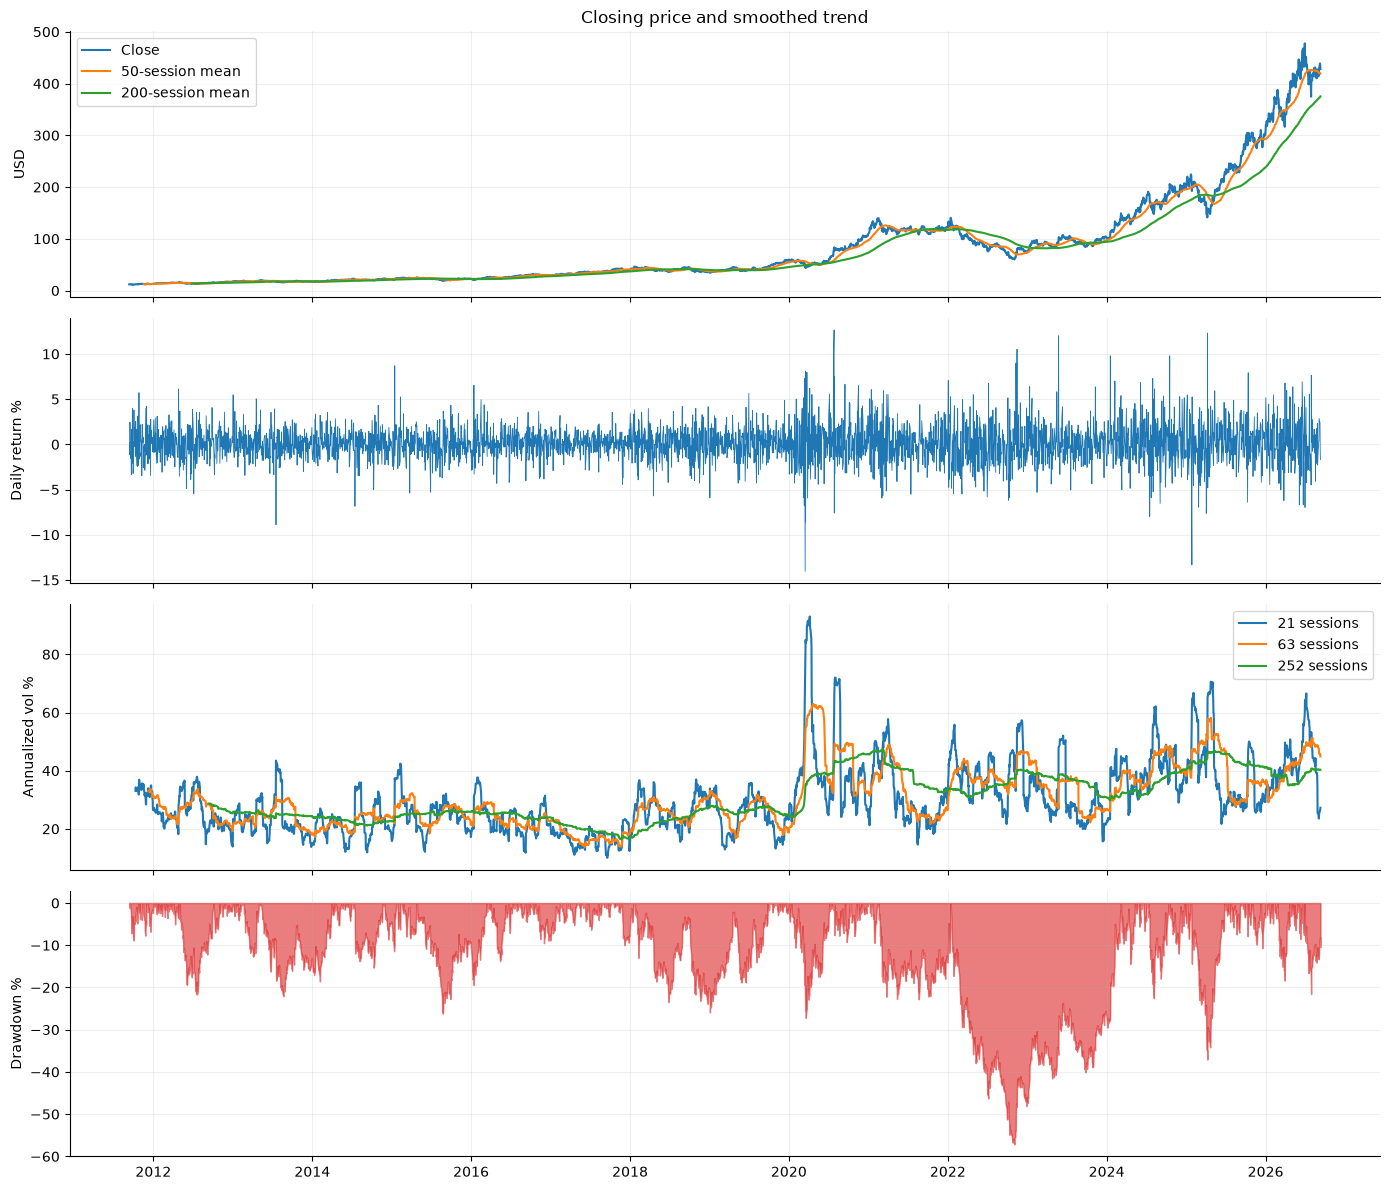

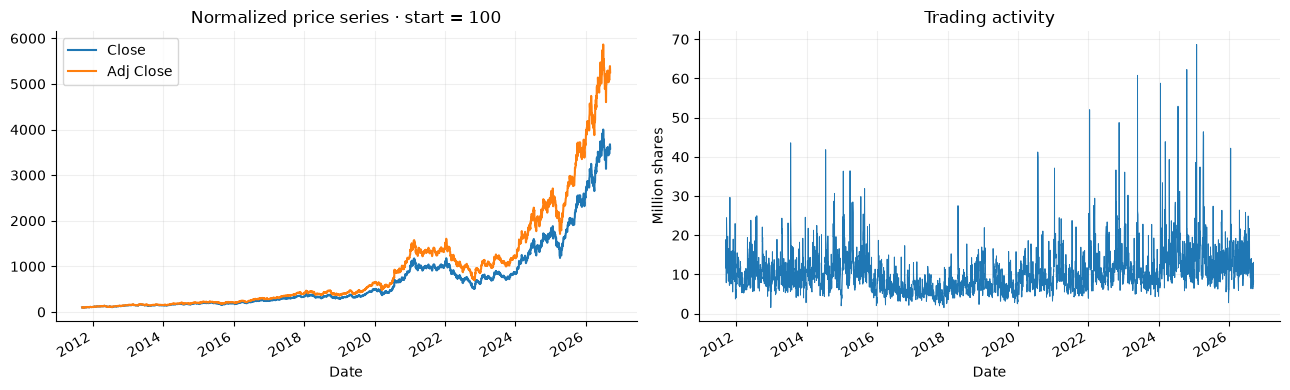

In [4]:
daily=df.copy()
daily["Return"]=daily.Close.pct_change(fill_method=None)
daily["Log_return"]=np.log(daily.Close).diff()
daily["Adjusted_return"]=daily["Adj Close"].pct_change(fill_method=None)
daily["Overnight_return"]=daily.Open/daily.Close.shift()-1
daily["Intraday_return"]=daily.Close/daily.Open-1
daily["Range_pct"]=(daily.High-daily.Low)/daily.Close
daily["Drawdown"]=daily.Close/daily.Close.cummax()-1
for w in [21,63,252]:
    daily[f"Vol_{w}"]=daily.Return.rolling(w).std()*np.sqrt(252)
    daily[f"Mean_return_{w}"]=daily.Return.rolling(w).mean()
assert np.allclose(((1+daily.Overnight_return)*(1+daily.Intraday_return)-1).iloc[1:],daily.Return.iloc[1:])
fig,axes=plt.subplots(4,1,figsize=(14,12),sharex=True)
axes[0].plot(daily.index,daily.Close,label="Close")
for w in [50,200]: axes[0].plot(daily.index,daily.Close.rolling(w).mean(),label=f"{w}-session mean")
axes[0].set(title="Closing price and smoothed trend",ylabel="USD"); axes[0].legend()
axes[1].plot(daily.index,daily.Return*100,lw=.6); axes[1].set_ylabel("Daily return %")
for w in [21,63,252]: axes[2].plot(daily.index,daily[f"Vol_{w}"]*100,label=f"{w} sessions")
axes[2].set_ylabel("Annualized vol %"); axes[2].legend()
axes[3].fill_between(daily.index,daily.Drawdown*100,0,color="#dc2626",alpha=.6); axes[3].set_ylabel("Drawdown %")
plt.tight_layout(); plt.show()
fig,axes=plt.subplots(1,2,figsize=(13,4))
(daily[["Close","Adj Close"]]/daily[["Close","Adj Close"]].iloc[0]*100).plot(ax=axes[0],title="Normalized price series · start = 100")
(daily.Volume/1e6).plot(ax=axes[1],title="Trading activity",ylabel="Million shares",lw=.7)
plt.tight_layout(); plt.show()

## 5 · Indexed weekly, monthly and yearly summaries
Weeks run **Monday–Sunday**, indexed with `W-SUN`; months and years use calendar PeriodIndex values. OHLC aggregation uses first/max/min/last and volume uses sum. Period returns compare successive period-end closes. The first period return is unavailable because its previous-period reference close is absent.

Tables include session counts, mean daily return, annualized daily volatility and within-period drawdown. Complete-return comparisons exclude boundary periods, session gaps and unexpected records, and require the preceding period to be complete too. Missing periods remain explicit rather than being compressed or forward-filled.

market_Weekly: 783 rows; complete table retained in TABLES
market_Monthly: 181 rows; complete table retained in TABLES
market_Yearly: 16 rows; complete table retained in TABLES
descriptive_price_trends: 4 rows; complete table retained in TABLES
Log-price slopes describe the historical sample; they are not forecasts or valid random-walk significance tests.


,Open,High,Low,Close,Adj_Close,Volume,Observations,Mean_daily_return,Daily_return_std,Positive_days,Return,Adjusted_return,Annualized_daily_vol,Within_period_drawdown,Expected_session,Missing_session,Unexpected_record,Partial_boundary_period,Complete,Return_usable
2011-09-12/2011-09-18,11.76,12.51,11.61,12.41,8.464075,74820100,5,0.009819,0.017980,3,NaN,NaN,0.285419,-0.011706,5,0,0,False,True,False
2011-09-19/2011-09-25,12.18,12.31,11.29,11.71,7.986648,77982000,5,-0.011412,0.018170,1,-0.056406,-0.056406,0.288442,-0.057283,5,0,0,False,True,True
2011-09-26/2011-10-02,11.59,12.16,11.30,11.43,7.795678,73782000,5,-0.004519,0.027950,2,-0.023911,-0.023911,0.443696,-0.049085,5,0,0,False,True,True
2011-10-03/2011-10-09,11.35,11.88,11.26,11.80,8.048031,79830800,5,0.006529,0.018682,3,0.032371,0.032371,0.296575,-0.002536,5,0,0,False,True,True
2011-10-10/2011-10-16,11.96,12.33,11.85,12.30,8.389047,54629600,5,0.008426,0.015202,4,0.042373,0.042373,0.241322,-0.013311,5,0,0,False,True,True
2011-10-17/2011-10-23,12.19,12.29,11.64,12.18,8.307207,47390200,5,-0.001712,0.024904,2,-0.009756,-0.009756,0.395340,-0.032760,5,0,0,False,True,True
2011-10-24/2011-10-30,12.16,13.06,12.12,12.74,8.689141,77318600,5,0.009448,0.032607,3,0.045977,0.045976,0.517614,-0.023237,5,0,0,False,True,True
2011-10-31/2011-11-06,12.63,13.06,12.22,12.98,8.852835,57056000,5,0.003830,0.015049,3,0.018838,0.018839,0.238892,-0.013471,5,0,0,False,True,True
2011-11-07/2011-11-13,12.93,13.02,12.42,12.95,8.832372,54738400,5,-0.000265,0.022150,3,-0.002311,-0.002311,0.351614,-0.040000,5,0,0,False,True,True
2011-11-14/2011-11-20,12.99,13.09,12.48,12.66,8.634583,56446500,5,-0.004452,0.012868,2,-0.022394,-0.022394,0.204268,-0.032110,5,0,0,False,True,True


,Open,High,Low,Close,Adj_Close,Volume,Observations,Mean_daily_return,Daily_return_std,Positive_days,Return,Adjusted_return,Annualized_daily_vol,Within_period_drawdown,Expected_session,Missing_session,Unexpected_record,Partial_boundary_period,Complete,Return_usable
2011-09,11.76,12.510000,11.29,11.43,7.795678,226584100,15,-0.002884,0.022253,6,NaN,NaN,0.353261,-0.078969,15,0,0,True,False,False
2011-10,11.35,13.060000,11.26,12.62,8.607301,268092300,21,0.004954,0.021973,12,0.104112,0.104112,0.348816,-0.039837,21,0,0,False,True,False
2011-11,12.34,13.090000,12.00,12.92,8.811913,247777900,21,0.001310,0.020074,10,0.023772,0.023772,0.318659,-0.077217,21,0,0,False,True,True
2011-12,12.95,13.360000,12.31,12.91,8.805092,216266300,21,0.000096,0.016700,11,-0.000774,-0.000774,0.265102,-0.068079,21,0,0,False,True,True
2012-01,13.11,14.430000,13.04,14.08,9.603072,217702700,20,0.004474,0.016387,11,0.090627,0.090627,0.260139,-0.026753,20,0,0,False,True,True
2012-02,14.10,14.800000,13.79,14.52,9.903172,182242800,20,0.001643,0.014660,14,0.031250,0.031250,0.232727,-0.032832,20,0,0,False,True,True
2012-03,14.65,15.510000,14.10,15.28,10.421515,153352800,22,0.002428,0.014985,9,0.052342,0.052341,0.237883,-0.032787,22,0,0,False,True,True
2012-04,15.27,16.150000,14.60,15.58,10.626124,186922800,20,0.001162,0.020095,10,0.019634,0.019633,0.318998,-0.050649,20,0,0,False,True,True
2012-05,15.61,16.129999,13.66,13.73,9.364358,263314700,22,-0.005609,0.015873,6,-0.118742,-0.118742,0.251972,-0.147205,22,0,0,False,True,True
2012-06,13.40,14.200000,12.87,13.96,9.521228,257692100,21,0.001015,0.021589,11,0.016752,0.016752,0.342719,-0.058033,21,0,0,False,True,True


,Open,High,Low,Close,Adj_Close,Volume,Observations,Mean_daily_return,Daily_return_std,Positive_days,Return,Adjusted_return,Annualized_daily_vol,Within_period_drawdown,Expected_session,Missing_session,Unexpected_record,Partial_boundary_period,Complete,Return_usable
2011,11.760000,13.360000,11.260000,12.910000,8.805092,958720600,78,0.001210,0.019963,39,NaN,NaN,0.316896,-0.088638,78,0,0,True,False,False
2012,13.110000,17.469999,12.140000,17.160000,12.125274,2646239300,250,0.001267,0.016021,133,0.329202,0.377075,0.254327,-0.216718,250,0,0,False,True,False
2013,17.760000,20.299999,15.700000,17.440001,12.666843,2613337200,252,0.000183,0.015409,121,0.016317,0.044665,0.244610,-0.220683,252,0,0,False,True,True
2014,17.389999,23.540001,16.440001,22.379999,16.620590,2787484400,252,0.001092,0.014231,128,0.283257,0.312134,0.225909,-0.152941,252,0,0,False,True,True
2015,22.450001,25.770000,17.320000,22.750000,17.432436,3085614800,252,0.000197,0.016305,123,0.016533,0.048846,0.258834,-0.261708,252,0,0,False,True,True
2016,22.240000,31.620001,20.450001,28.750000,22.856871,1787495700,252,0.001043,0.015097,134,0.263736,0.311169,0.239660,-0.137566,252,0,0,False,True,True
2017,29.250000,43.020000,28.980000,39.650002,32.549706,1438759300,251,0.001337,0.010569,144,0.379130,0.424067,0.167783,-0.100256,251,0,0,False,True,True
2018,40.509998,46.570000,35.220001,36.910000,31.408567,2018670000,251,-0.000136,0.017292,122,-0.069105,-0.035058,0.274504,-0.239112,251,0,0,False,True,True
2019,36.200001,59.709999,34.209999,58.099998,51.774483,1913965800,252,0.001922,0.015543,142,0.574099,0.648419,0.246741,-0.171070,252,0,0,False,True,True
2020,59.599998,109.699997,42.700001,109.040001,99.753036,2400076000,253,0.002903,0.028760,138,0.876764,0.926683,0.456552,-0.272381,253,0,0,False,True,True


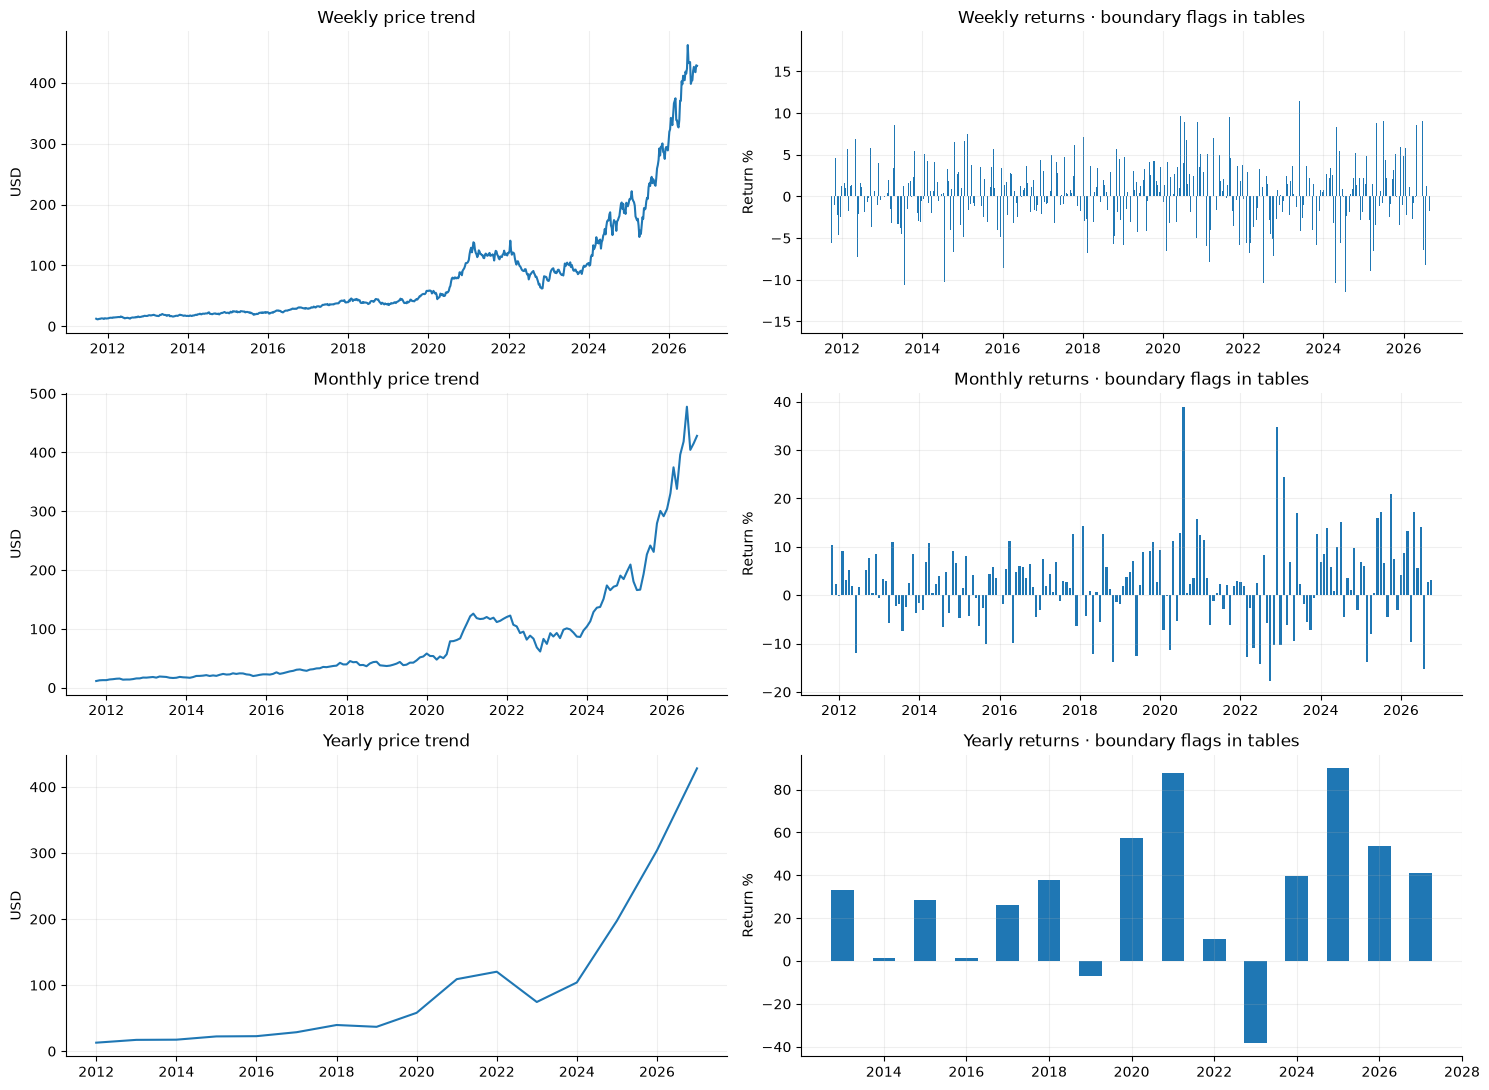

,Frequency,N,Log_price_slope_per_year,Fitted_growth_pct,Start_close,End_close
0,Daily,3771,0.212101,23.627229,11.94,428.029999
1,Weekly,783,0.212217,23.641672,12.41,428.029999
2,Monthly,181,0.212383,23.662141,11.43,428.029999
3,Yearly,16,0.219629,24.561493,12.91,428.029999


In [5]:
def aggregate_period(name,freq):
    g=daily.groupby(daily.index.to_period(freq))
    t=g.agg(Open=("Open","first"),High=("High","max"),Low=("Low","min"),Close=("Close","last"),
        Adj_Close=("Adj Close","last"),Volume=("Volume","sum"),Observations=("Close","size"),
        Mean_daily_return=("Return","mean"),Daily_return_std=("Return","std"),
        Positive_days=("Return",lambda s:int((s>0).sum())))
    t=t.reindex(pd.period_range(t.index.min(),t.index.max(),freq=freq))
    t["Return"]=t.Close.pct_change(fill_method=None)
    t["Adjusted_return"]=t.Adj_Close.pct_change(fill_method=None)
    t["Annualized_daily_vol"]=t.Daily_return_std*np.sqrt(252)
    t["Within_period_drawdown"]=g.Close.apply(lambda s:float((s/s.cummax()-1).min()))
    t=t.join(calendar_tables[name][["Expected_session","Missing_session","Unexpected_record","Partial_boundary_period"]])
    t["Complete"]=(~t.Partial_boundary_period.fillna(True).astype(bool)&t.Missing_session.eq(0)&t.Unexpected_record.eq(0))
    t["Return_usable"]=t.Complete&t.Complete.shift(1,fill_value=False)&t.Return.notna()
    return t
period_tables={name:aggregate_period(name,freq) for name,freq in FREQUENCIES.items()}
for name,t in period_tables.items():
    show_table(f"market_{name}",t,20 if name=="Yearly" else 12)
    assert int(t.Observations.sum())==len(daily)
    assert np.isclose(t.Volume.sum(),daily.Volume.sum())
fig,axes=plt.subplots(3,2,figsize=(15,11))
for row,(name,t) in enumerate(period_tables.items()):
    x=t.index.to_timestamp(how="end")
    axes[row,0].plot(x,t.Close); axes[row,0].set(title=f"{name} price trend",ylabel="USD")
    axes[row,1].bar(x,t.Return*100,width={"Weekly":4,"Monthly":20,"Yearly":200}[name])
    axes[row,1].set(title=f"{name} returns · boundary flags in tables",ylabel="Return %")
plt.tight_layout(); plt.show()
trend=[]
for name,t in [("Daily",daily),*period_tables.items()]:
    s=t.Close.dropna(); dates=s.index.to_timestamp() if isinstance(s.index,pd.PeriodIndex) else s.index
    slope=stats.linregress((dates-dates[0]).days/365.25,np.log(s)).slope
    trend.append({"Frequency":name,"N":len(s),"Log_price_slope_per_year":slope,
        "Fitted_growth_pct":100*np.expm1(slope),"Start_close":s.iloc[0],"End_close":s.iloc[-1]})
show_table("descriptive_price_trends",pd.DataFrame(trend))
print("Log-price slopes describe the historical sample; they are not forecasts or valid random-walk significance tests.")

## 6 · Calendar seasonality and stability across years
Inspect return patterns by weekday, month, ISO week of year and trading-session position within the month. Price-level averages are confounded by growth. Heatmaps show whether patterns persist across years. Weekly labels use ISO year/week consistently across New Year boundaries.

Error bars are descriptive standard errors, not dependence-robust confidence intervals. Yearly returns describe regimes; one observation per year cannot identify within-year seasonality. Partial periods are excluded from period-return heatmaps. Session-position analysis uses complete months only, so a truncated starting month does not shift session numbers.

seasonality_Weekday: 5 rows; complete table retained in TABLES
seasonality_Month: 12 rows; complete table retained in TABLES
seasonality_ISO_week: 53 rows; complete table retained in TABLES
seasonality_Session_position: 23 rows; complete table retained in TABLES
monthly_return_heatmap: 16 rows; complete table retained in TABLES
monthly_period_seasonality: 12 rows; complete table retained in TABLES


,Count,Mean,Median,Std,Positive_fraction,Minimum,Maximum,SE
Mon,706,0.000891,0.001497,0.020653,0.528329,-0.140341,0.126522,0.000777
Tue,776,0.001969,0.001102,0.018872,0.528351,-0.076036,0.105220,0.000677
Wed,773,0.002287,0.001572,0.019670,0.534282,-0.085909,0.122940,0.000707
Thu,759,0.001275,0.000343,0.022403,0.503294,-0.088889,0.120049,0.000813
Fri,756,-0.000731,0.000000,0.018666,0.489418,-0.067226,0.096927,0.000679


,Count,Mean,Median,Std,Positive_fraction,Minimum,Maximum,SE
Group,,,,,,,,
1,304,0.002960,0.002057,0.024397,0.539474,-0.133270,0.097912,0.001399
2,288,0.000911,0.000704,0.019580,0.510417,-0.069520,0.070011,0.001154
3,326,0.000252,0.001157,0.024533,0.515337,-0.140341,0.081069,0.001359
4,311,0.000419,0.000000,0.021439,0.479100,-0.076354,0.122940,0.001216
5,318,0.001068,0.000000,0.018591,0.493711,-0.047255,0.120049,0.001043
6,315,0.001548,0.002624,0.019400,0.555556,-0.066885,0.069351,0.001093
7,319,0.001328,0.001085,0.023988,0.520376,-0.088889,0.126522,0.001343
8,331,0.000150,0.000543,0.016069,0.513595,-0.052598,0.061339,0.000883
9,306,0.000668,0.001557,0.017389,0.516340,-0.065288,0.066460,0.000994


,Count,Mean,Median,Std,Positive_fraction,Minimum,Maximum,SE
Group,,,,,,,,
1,63,0.003338,-0.002674,0.024568,0.460317,-0.059146,0.070568,0.003095
2,74,0.005062,0.004033,0.021965,0.581081,-0.039044,0.065430,0.002553
3,67,0.006621,0.004747,0.026194,0.611940,-0.048557,0.097912,0.003200
4,68,0.001601,0.003566,0.019433,0.573529,-0.054436,0.050862,0.002357
5,75,-0.001982,0.000583,0.023971,0.506667,-0.133270,0.052467,0.002768
6,75,0.003522,0.004967,0.022665,0.573333,-0.045481,0.070011,0.002617
7,73,0.004137,0.005828,0.018122,0.602740,-0.053083,0.052492,0.002121
8,62,-0.003179,-0.004696,0.017614,0.354839,-0.047619,0.037429,0.002237
9,75,-0.002142,-0.001903,0.021030,0.440000,-0.069520,0.045073,0.002428


,Count,Mean,Median,Std,Positive_fraction,Minimum,Maximum,SE
Group,,,,,,,,
1,179,0.004669,0.004922,0.022282,0.620112,-0.069812,0.070568,0.001665
2,179,0.001836,0.000555,0.019083,0.502793,-0.059146,0.051408,0.001426
3,179,0.001494,0.001472,0.019793,0.536313,-0.076354,0.068538,0.001479
4,179,0.001495,0.003665,0.020376,0.569832,-0.067226,0.067364,0.001523
5,179,0.001995,0.000000,0.019553,0.491620,-0.066866,0.059597,0.001461
6,179,0.001975,0.002471,0.018549,0.525140,-0.058834,0.070011,0.001386
7,179,0.000866,0.000000,0.020247,0.497207,-0.059164,0.122940,0.001513
8,179,0.001698,0.000564,0.021762,0.513966,-0.064092,0.089846,0.001627
9,179,0.002737,0.001703,0.020939,0.536313,-0.067956,0.079206,0.001565


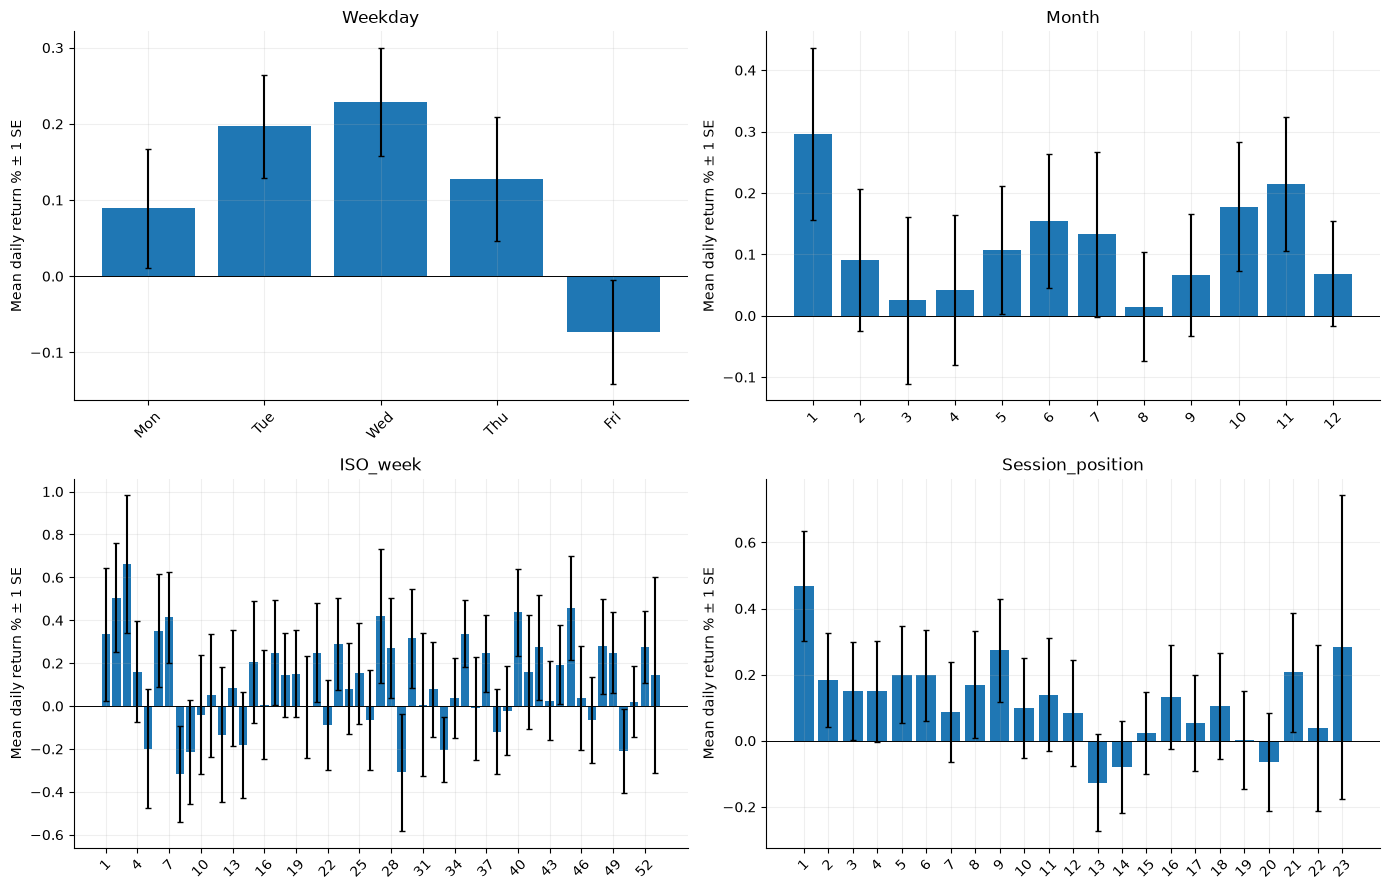

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.377181,-0.077401
2012,9.062743,3.125004,5.234155,1.963352,-11.874200,1.675168,0.071635,5.225480,7.619047,0.505689,8.616358,-0.636946
2013,3.379953,2.874860,-5.808216,10.994761,-2.201258,-1.822080,-7.314411,-2.473499,2.415457,8.549533,-3.693646,-1.635640
2014,-2.981654,6.796688,10.791371,0.399600,2.288553,4.036965,-6.498361,4.700003,-3.629418,9.117939,6.584917,-4.644227
2015,1.474531,8.014098,-4.280477,4.088590,-0.654664,-6.466234,-2.642001,-10.085940,4.376262,5.831321,3.642993,-0.043938
2016,-1.758240,5.369122,11.252661,-9.961834,4.790162,6.108415,5.909269,3.455720,6.437023,1.667212,-4.533762,-3.166051
2017,7.513043,1.811710,4.353355,0.700364,6.924708,-1.131226,2.860412,2.808682,1.568834,12.729701,-6.449334,0.126270
2018,14.274904,-4.325762,0.945790,-12.134364,0.650195,-5.529714,12.718812,5.799562,1.284407,-13.722829,-1.338578,-1.808993
2019,1.923595,3.801171,4.891165,6.982424,-12.482887,2.138200,8.833299,0.000000,9.031195,11.080038,2.827811,9.436802


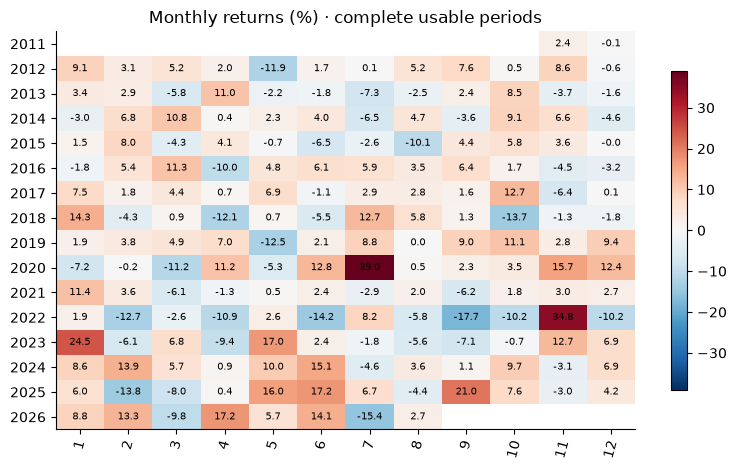

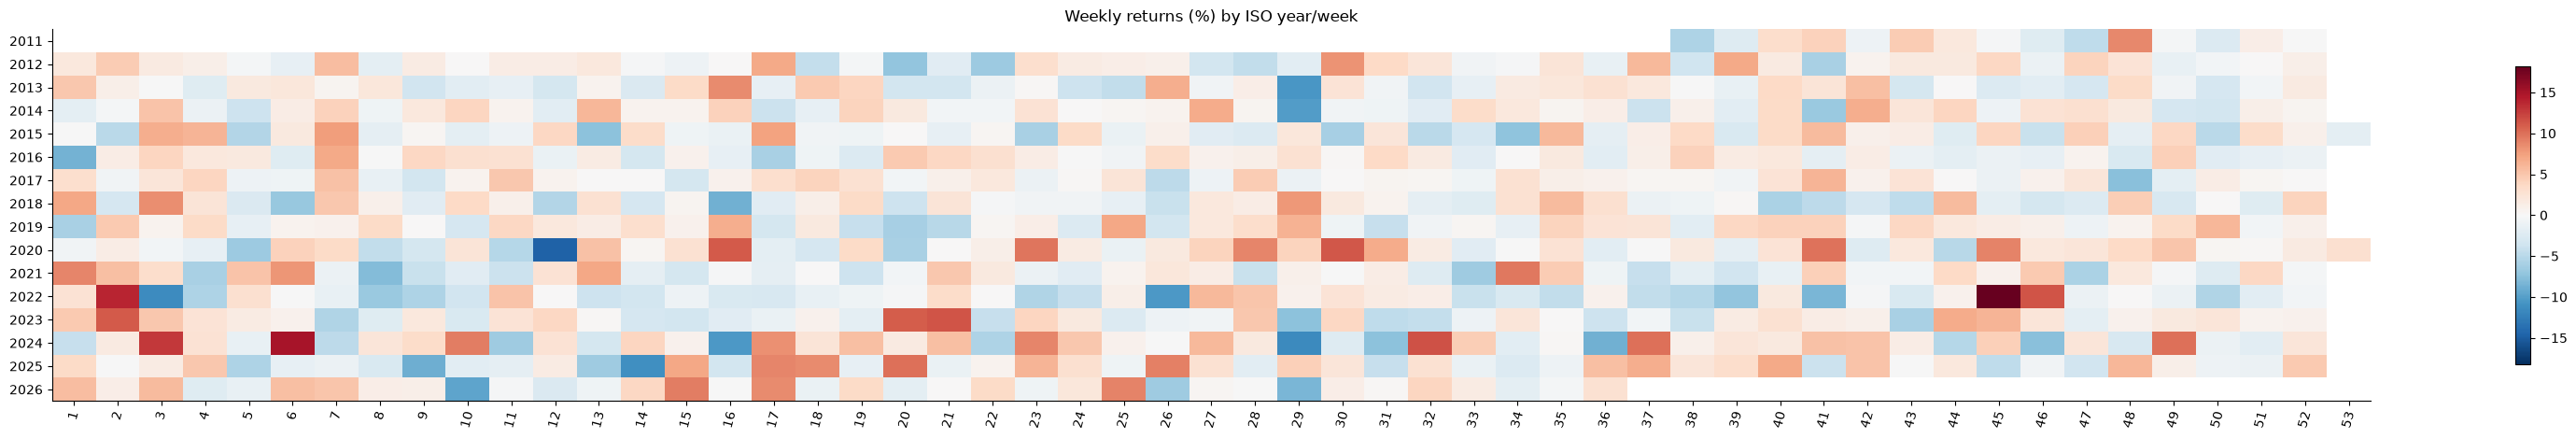

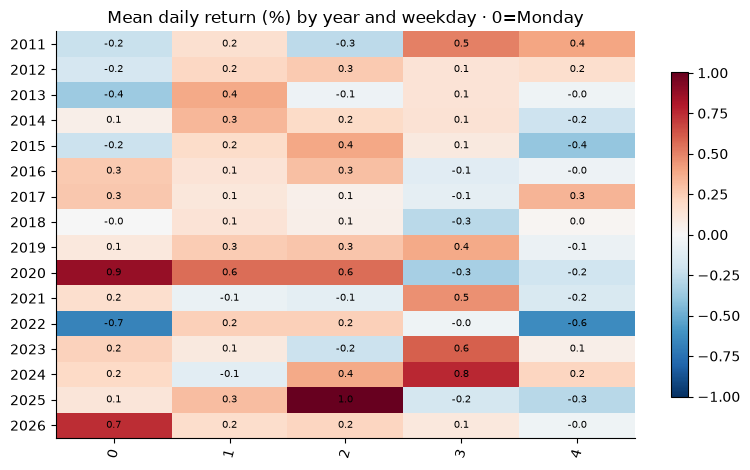

,Count,Mean,Median,Std,Positive_fraction,Minimum,Maximum,SE
Group,,,,,,,,
1,15,0.057981,0.059902,0.077463,0.800000,-0.071601,0.244865,0.020001
2,15,0.017032,0.031250,0.081192,0.666667,-0.137541,0.139076,0.020964
3,15,0.001488,0.009458,0.074443,0.533333,-0.112370,0.112527,0.019221
4,15,0.007481,0.007004,0.086940,0.666667,-0.121344,0.171948,0.022448
5,15,0.022538,0.022886,0.084981,0.666667,-0.124829,0.169514,0.021942
6,15,0.032465,0.023633,0.087763,0.666667,-0.142183,0.171581,0.022660
7,15,0.028781,0.000716,0.124228,0.533333,-0.153527,0.389642,0.032076
8,15,0.001560,0.020319,0.047803,0.600000,-0.100859,0.057996,0.012343
9,14,0.016045,0.019327,0.089342,0.714286,-0.177445,0.209728,0.023878


In [6]:
def grouped_stats(values,groups):
    f=pd.DataFrame({"Return":values,"Group":groups}).dropna()
    t=f.groupby("Group").Return.agg(Count="count",Mean="mean",Median="median",Std="std",
        Positive_fraction=lambda s:float((s>0).mean()),Minimum="min",Maximum="max")
    t["SE"]=t.Std/np.sqrt(t.Count)
    return t
valid_daily=~calendar.loc[daily.index,"Unexpected_record"]
if calendar.Missing_session.any():
    positions=sessions.get_indexer(daily.index)
    valid_daily &= pd.Series(np.r_[False,np.diff(positions)==1],index=daily.index)
season_daily=daily.Return.where(valid_daily)
iso=daily.index.isocalendar()
weekday=grouped_stats(season_daily,daily.index.dayofweek).reindex(range(5))
weekday.index=["Mon","Tue","Wed","Thu","Fri"]
month=grouped_stats(season_daily,daily.index.month)
week=grouped_stats(season_daily,iso.week.to_numpy())
position=daily.groupby(daily.index.to_period("M")).cumcount()+1
month_ok=daily.index.to_period("M").isin(period_tables["Monthly"].index[period_tables["Monthly"].Complete])
session_position=grouped_stats(season_daily.where(month_ok),position)
groups={"Weekday":weekday,"Month":month,"ISO_week":week,"Session_position":session_position}
for name,t in groups.items(): show_table(f"seasonality_{name}",t,53)
fig,axes=plt.subplots(2,2,figsize=(14,9))
for ax,(name,t) in zip(axes.flat,groups.items()):
    ax.bar(range(len(t)),t.Mean*100)
    ax.errorbar(range(len(t)),t.Mean*100,yerr=t.SE*100,fmt="none",color="black",capsize=2)
    step=max(1,len(t)//15); ticks=np.arange(len(t))[::step]
    ax.set_xticks(ticks,labels=t.index.astype(str)[::step],rotation=45)
    ax.set(title=name,ylabel="Mean daily return % ± 1 SE"); ax.axhline(0,color="black",lw=.7)
plt.tight_layout(); plt.show()
monthly=period_tables["Monthly"]
mc=monthly.loc[monthly.Return_usable].copy()
mc["Year"]=mc.index.year; mc["Month"]=mc.index.month
grid=mc.pivot(index="Year",columns="Month",values="Return").reindex(columns=range(1,13))*100
show_table("monthly_return_heatmap",grid,30)
heatmap(grid,"Monthly returns (%) · complete usable periods",True)
weekly=period_tables["Weekly"]
wc=weekly.loc[weekly.Return_usable].copy(); wi=wc.index.start_time.isocalendar()
wc["ISO_year"]=wi.year.to_numpy(); wc["ISO_week"]=wi.week.to_numpy()
heatmap(wc.pivot(index="ISO_year",columns="ISO_week",values="Return")*100,"Weekly returns (%) by ISO year/week")
weekday_year=pd.DataFrame({"Return":season_daily,"Year":daily.index.year,"Weekday":daily.index.dayofweek}).pivot_table(
    index="Year",columns="Weekday",values="Return",aggfunc="mean")*100
heatmap(weekday_year,"Mean daily return (%) by year and weekday · 0=Monday",True)
show_table("monthly_period_seasonality",grouped_stats(mc.Return,mc.index.month))

## 7 · Seasonal evidence: tests and decomposition
Kruskal–Wallis screens compare calendar-group return distributions; serial dependence weakens their independence assumptions. Benjamini–Hochberg adjustment covers these three screens. Treat results as exploratory hypotheses.

Robust STL decomposes log prices. Five-session and 21-session cycles approximate trading weeks/months, not exact calendar intervals. Monthly STL with period 12 examines an annual cycle. Only contiguous series are decomposed. STL uses future observations retrospectively; its components must not be reused as causal forecasting inputs. Seasonal strength is descriptive, not a significance test.

exploratory_calendar_tests: 3 rows; complete table retained in TABLES
STL_strength: 3 rows; complete table retained in TABLES


,Grouping,Groups,Statistic,p_value,BH_adjusted_p
0,Weekday,5,10.219796,0.036884,0.110651
1,Month,12,7.214394,0.781465,0.781465
2,ISO week,53,50.379142,0.537850,0.781465


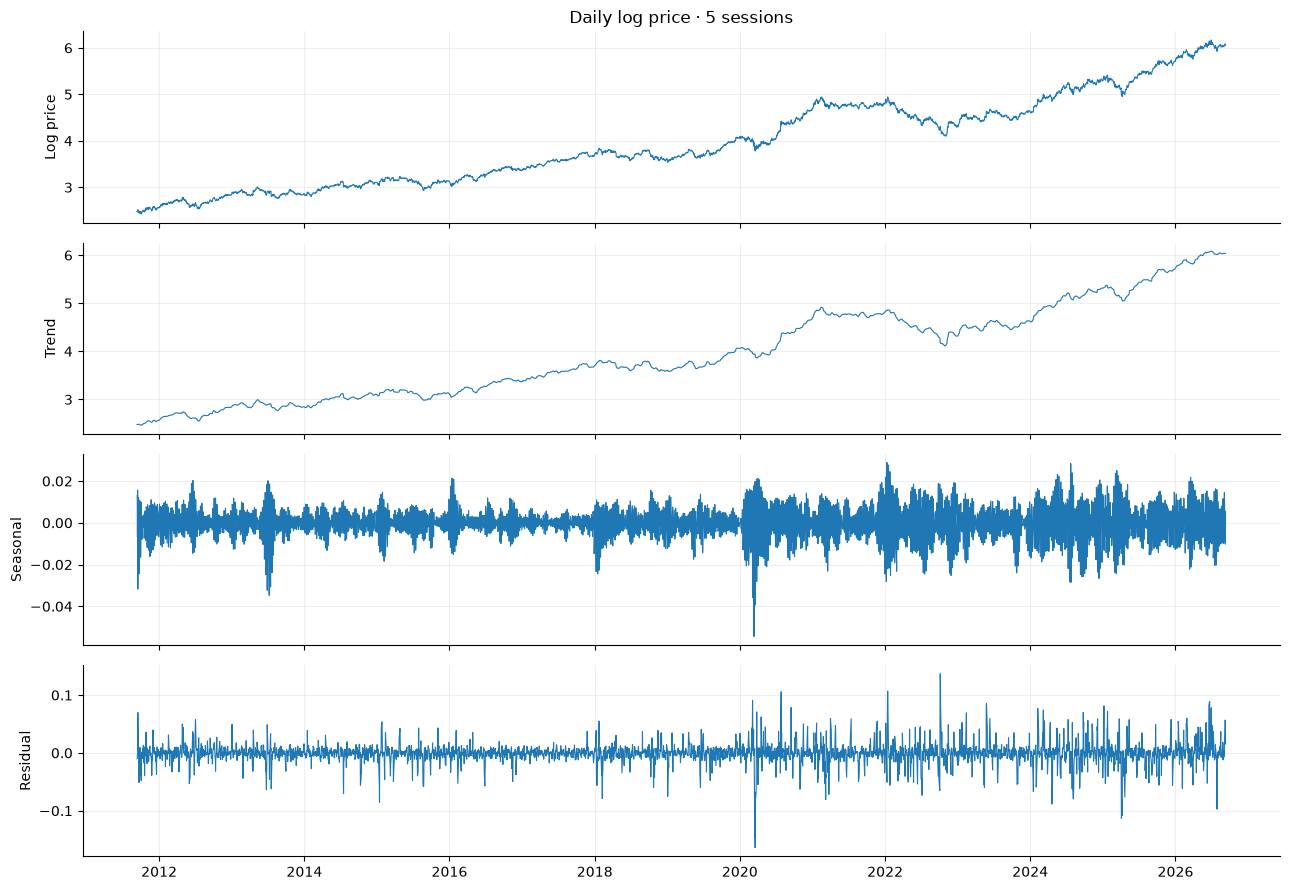

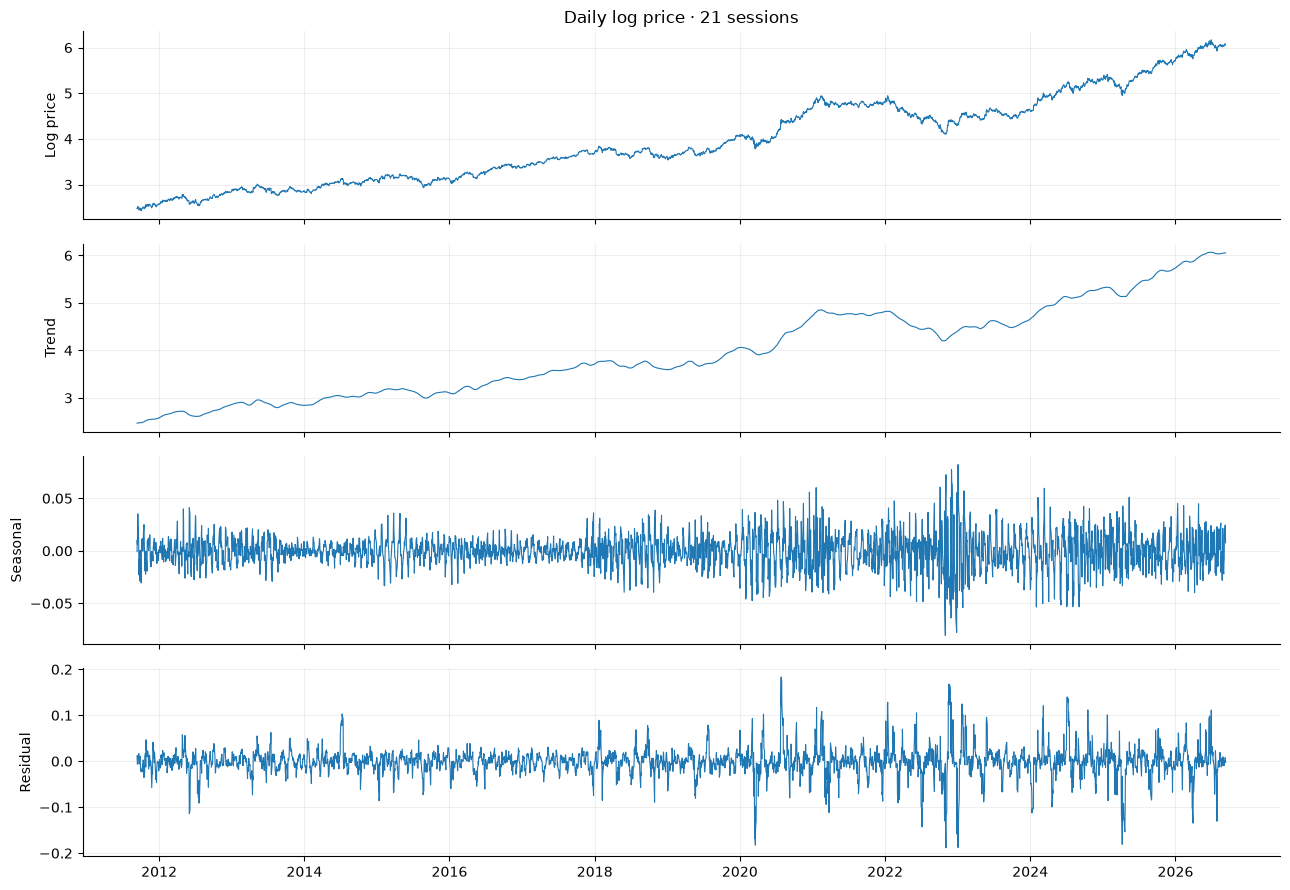

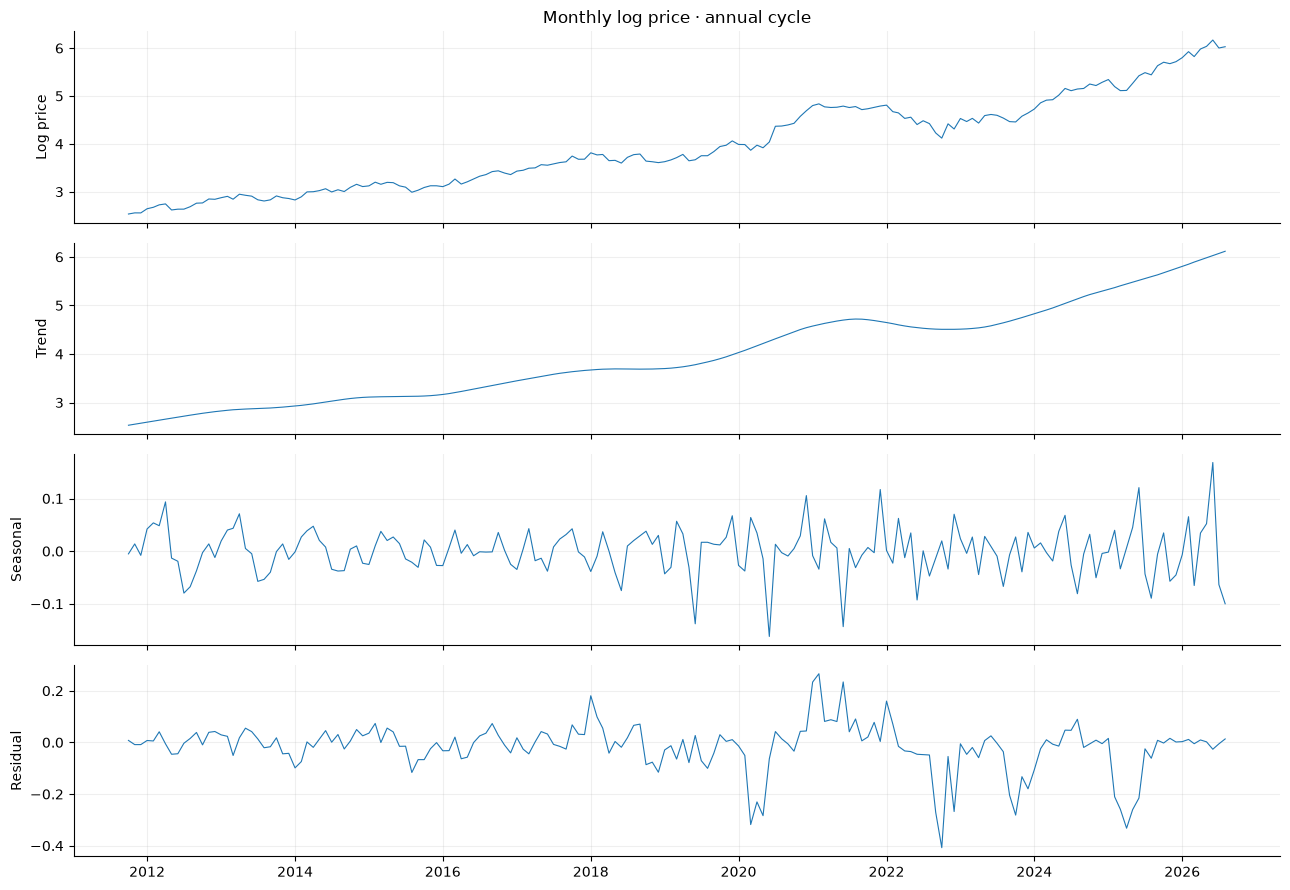

,Series,Period,Seasonal_strength
0,Daily log price · 5 sessions,5,0.024533
1,Daily log price · 21 sessions,21,0.022649
2,Monthly log price · annual cycle,12,0.070661


In [7]:
screens=[]
for name,g in [("Weekday",daily.index.dayofweek),("Month",daily.index.month),("ISO week",iso.week.to_numpy())]:
    f=pd.DataFrame({"r":season_daily,"g":g}).dropna()
    arrays=[t.r.to_numpy() for _,t in f.groupby("g") if len(t)>=5]
    statistic,p=stats.kruskal(*arrays)
    screens.append({"Grouping":name,"Groups":len(arrays),"Statistic":statistic,"p_value":p})
screens=pd.DataFrame(screens); screens["BH_adjusted_p"]=multipletests(screens.p_value,method="fdr_bh")[1]
show_table("exploratory_calendar_tests",screens)
decompose=[]
if not calendar.Missing_session.any() and not calendar.Unexpected_record.any():
    decompose=[("Daily log price · 5 sessions",np.log(daily.Close),5),
               ("Daily log price · 21 sessions",np.log(daily.Close),21)]
else: print("Daily STL skipped because exchange-session continuity failed.")
m=monthly.loc[monthly.Complete,"Close"]
if len(m)>=36 and np.all(np.diff(m.index.asi8)==1):
    decompose.append(("Monthly log price · annual cycle",np.log(m),12))
stl_rows=[]
for name,s,period in decompose:
    result=STL(s.to_numpy(),period=period,robust=True).fit()
    denominator=np.var(result.seasonal+result.resid)
    strength=max(0.,1-np.var(result.resid)/denominator) if denominator else np.nan
    stl_rows.append({"Series":name,"Period":period,"Seasonal_strength":strength})
    x=s.index.to_timestamp() if isinstance(s.index,pd.PeriodIndex) else s.index
    fig,axes=plt.subplots(4,1,figsize=(13,9),sharex=True)
    for ax,label,values in zip(axes,["Log price","Trend","Seasonal","Residual"],[s.to_numpy(),result.trend,result.seasonal,result.resid]):
        ax.plot(x,values,lw=.8); ax.set_ylabel(label)
    axes[0].set_title(name); plt.tight_layout(); plt.show()
show_table("STL_strength",pd.DataFrame(stl_rows))

## 8 · Outliers, anomalies and heavy tails
Daily flags: return IQR fences (1.5×IQR), median/MAD robust score (absolute score >3.5), and trailing return z-score (absolute score >4). Trailing scores use only the **previous 63 rows**, minimum 30. Volume spikes use trailing log-volume scores; range anomalies use robust scores.

Full-sample IQR/MAD flags are retrospective; none are deleted. Several flags may identify the same date. Weekly/monthly/yearly period-return outliers are identified separately. Yearly samples are small. High or low price levels alone are not labelled anomalous in a trending stock.

daily_anomalies: 220 rows; complete table retained in TABLES
anomaly_counts_Weekly: 783 rows; complete table retained in TABLES
period_outliers_Weekly: 29 rows; complete table retained in TABLES
anomaly_counts_Monthly: 181 rows; complete table retained in TABLES
period_outliers_Monthly: 4 rows; complete table retained in TABLES
anomaly_counts_Yearly: 16 rows; complete table retained in TABLES
period_outliers_Yearly: 0 rows; complete table retained in TABLES
return_distributions: 4 rows; complete table retained in TABLES


,Close,Return,Volume,Range_pct,Overnight_return,Intraday_return,Return_IQR,Robust_z,Return_MAD,Trailing_return_z,Return_trailing,Trailing_volume_z,Volume_spike,Range_outlier,Any_flag
Date,,,,,,,,,,,,,,,
2020-03-16,44.900002,-0.140341,16628200,0.076837,-0.112770,-0.031075,True,-9.071593,True,-5.197502,True,1.580372,False,True,True
2025-01-27,192.309998,-0.133270,68667500,0.100515,-0.111952,-0.024005,True,-8.617222,True,-5.722335,True,5.198298,True,True,True
2020-07-27,83.250000,0.126522,39899200,0.035676,0.100947,0.023230,True,8.077811,True,5.126188,True,4.058335,True,False,True
2025-04-09,158.750000,0.122940,45612500,0.143118,-0.008276,0.132311,True,7.847591,True,4.036177,True,2.296246,False,True,True
2023-05-25,100.949997,0.120049,60793200,0.053393,0.076889,0.040078,True,7.661805,True,7.026483,True,6.602893,True,True,True
2022-11-15,80.459999,0.105220,48742400,0.036291,0.125275,-0.017822,True,6.708844,True,4.291237,True,4.175337,True,False,True
2024-10-17,205.839996,0.097930,62274700,0.051642,0.084649,0.012245,True,6.240414,True,3.404944,False,4.250903,True,True,True
2024-01-18,113.029999,0.097912,58783700,0.034593,0.080136,0.016457,True,6.239205,True,5.858949,True,5.886587,True,False,True
2020-07-24,73.900002,0.096927,41226800,0.074966,0.059819,0.035014,True,6.175955,True,4.530262,True,4.924220,True,True,True


,Return_IQR,Return_MAD,Return_trailing,Volume_spike,Range_outlier,Any_flag,Observed_days,Flagged_pct
Date,,,,,,,,
2011-09-12/2011-09-18,0,0,0,0,0,0,5,0.0
2011-09-19/2011-09-25,0,0,0,0,0,0,5,0.0
2011-09-26/2011-10-02,0,0,0,0,0,0,5,0.0
2011-10-03/2011-10-09,0,0,0,0,0,0,5,0.0
2011-10-10/2011-10-16,0,0,0,0,0,0,5,0.0
2011-10-17/2011-10-23,0,0,0,0,0,0,5,0.0
2011-10-24/2011-10-30,1,1,0,0,0,1,5,20.0
2011-10-31/2011-11-06,0,0,0,0,0,0,5,0.0
2011-11-07/2011-11-13,0,0,0,0,0,0,5,0.0


,Return,Volume,Robust_z,IQR_outlier,MAD_outlier
2020-03-16/2020-03-22,-0.147425,70402700,-4.526650,True,True
2024-07-15/2024-07-21,-0.115185,152887900,-3.568935,True,True
2022-01-17/2022-01-23,-0.114674,53342100,-3.553732,True,True
2025-03-31/2025-04-06,-0.111649,103116600,-3.463878,True,False
2013-07-15/2013-07-21,-0.105748,91626500,-3.288593,True,False
2024-04-15/2024-04-21,-0.103985,114090300,-3.236222,True,False
2022-06-27/2022-07-03,-0.103817,57361800,-3.231233,True,False
2014-07-14/2014-07-20,-0.102148,111235200,-3.181644,True,False
2026-03-02/2026-03-08,-0.095280,73335700,-2.977614,True,False
2025-02-24/2025-03-02,-0.089336,101956200,-2.801046,True,False


,Return_IQR,Return_MAD,Return_trailing,Volume_spike,Range_outlier,Any_flag,Observed_days,Flagged_pct
Date,,,,,,,,
2011-09,0,0,0,0,0,0,15,0.000000
2011-10,1,1,0,0,0,1,21,4.761905
2011-11,0,0,0,0,0,0,21,0.000000
2011-12,0,0,0,0,0,0,21,0.000000
2012-01,0,0,0,0,0,0,20,0.000000
2012-02,0,0,0,0,0,0,20,0.000000
2012-03,0,0,0,0,0,0,22,0.000000
2012-04,1,1,1,0,1,1,20,5.000000
2012-05,0,0,0,0,0,0,22,0.000000


,Return,Volume,Robust_z,IQR_outlier,MAD_outlier
2022-09,-0.177445,227317900,-2.858472,True,False
2023-01,0.244865,318689500,3.166187,True,False
2022-11,0.348172,357723500,4.639964,True,True
2020-07,0.389642,342293900,5.231575,True,True


,Return_IQR,Return_MAD,Return_trailing,Volume_spike,Range_outlier,Any_flag,Observed_days,Flagged_pct
Date,,,,,,,,
2011,1,1,0,0,0,1,78,1.282051
2012,3,2,1,0,2,4,250,1.600000
2013,4,1,2,1,1,4,252,1.587302
2014,3,1,1,0,0,3,252,1.190476
2015,5,2,2,0,5,8,252,3.174603
2016,5,1,1,0,1,5,252,1.984127
2017,1,0,1,0,0,1,251,0.398406
2018,3,1,0,1,0,3,251,1.195219
2019,5,2,1,0,1,6,252,2.380952


,Return,Volume,Robust_z,IQR_outlier,MAD_outlier


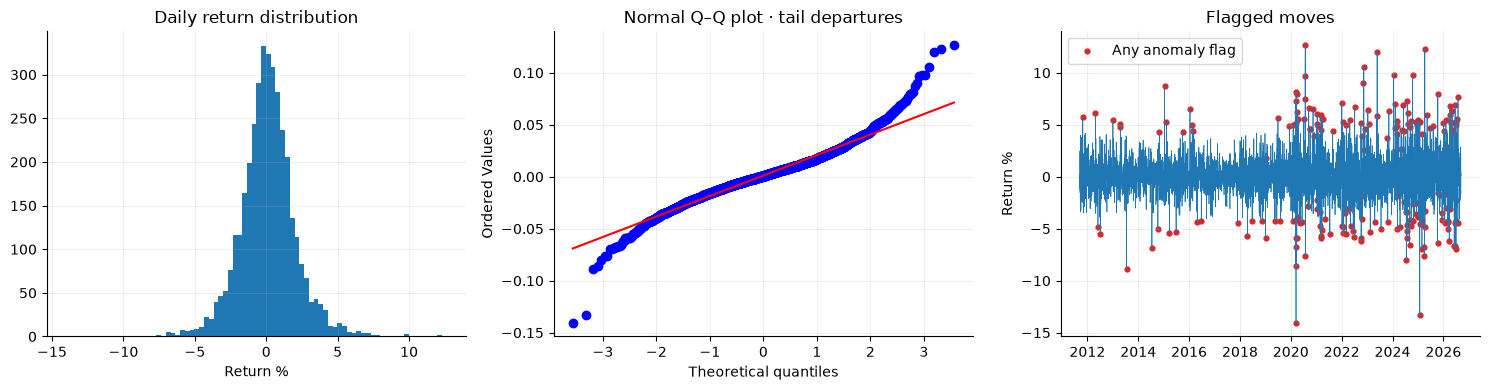

,Frequency,N,Mean,Std,Skew,Excess_kurtosis,P01,P05,Median,P95,P99
0,Daily,3770,0.001151,0.020103,0.190449,3.974371,-0.050379,-0.030079,0.000823,0.033759,0.055863
1,Weekly,781,0.005341,0.040014,0.168622,1.215733,-0.096654,-0.058484,0.004955,0.070693,0.112049
2,Monthly,178,0.023180,0.084084,0.673356,2.422253,-0.144792,-0.113326,0.022925,0.151660,0.268626
3,Yearly,13,0.299777,0.369676,0.047269,-0.263514,-0.343440,-0.193803,0.283257,0.885636,0.896281


In [8]:
def robust_score(s):
    median=s.median(); mad=(s-median).abs().median()
    return .67448975*(s-median)/mad if mad>0 else pd.Series(np.nan,index=s.index)
def iqr_flag(s):
    q1,q3=s.quantile([.25,.75]); width=q3-q1
    return (s<q1-1.5*width)|(s>q3+1.5*width)

anomalies=daily[["Close","Return","Volume","Range_pct","Overnight_return","Intraday_return"]].copy()
anomalies["Return_IQR"]=iqr_flag(daily.Return)
anomalies["Robust_z"]=robust_score(daily.Return)
anomalies["Return_MAD"]=anomalies.Robust_z.abs()>3.5
past=daily.Return.shift(1)
anomalies["Trailing_return_z"]=(daily.Return-past.rolling(63,min_periods=30).mean())/past.rolling(63,min_periods=30).std().replace(0,np.nan)
anomalies["Return_trailing"]=anomalies.Trailing_return_z.abs()>4
lv=np.log1p(daily.Volume.clip(lower=0)); pv=lv.shift(1)
anomalies["Trailing_volume_z"]=(lv-pv.rolling(63,min_periods=30).mean())/pv.rolling(63,min_periods=30).std().replace(0,np.nan)
anomalies["Volume_spike"]=anomalies.Trailing_volume_z>4
anomalies["Range_outlier"]=robust_score(daily.Range_pct)>3.5
FLAGS=["Return_IQR","Return_MAD","Return_trailing","Volume_spike","Range_outlier"]
anomalies["Any_flag"]=anomalies[FLAGS].any(axis=1)
show_table("daily_anomalies",anomalies.loc[anomalies.Any_flag].sort_values("Return",key=lambda s:s.abs(),ascending=False),25)
for name,freq in FREQUENCIES.items():
    counts=anomalies[FLAGS+["Any_flag"]].groupby(anomalies.index.to_period(freq)).sum()
    counts["Observed_days"]=anomalies.groupby(anomalies.index.to_period(freq)).size()
    counts["Flagged_pct"]=100*counts.Any_flag/counts.Observed_days
    show_table(f"anomaly_counts_{name}",counts,20)
    t=period_tables[name].loc[period_tables[name].Return_usable,["Return","Volume"]].copy()
    t["Robust_z"]=robust_score(t.Return); t["IQR_outlier"]=iqr_flag(t.Return); t["MAD_outlier"]=t.Robust_z.abs()>3.5
    show_table(f"period_outliers_{name}",t.loc[t.IQR_outlier|t.MAD_outlier].sort_values("Return"),25)
fig,axes=plt.subplots(1,3,figsize=(15,4))
axes[0].hist(daily.Return.dropna()*100,bins=80); axes[0].set(title="Daily return distribution",xlabel="Return %")
stats.probplot(daily.Return.dropna(),dist="norm",plot=axes[1]); axes[1].set_title("Normal Q–Q plot · tail departures")
axes[2].plot(daily.index,daily.Return*100,lw=.5)
flag=anomalies.Any_flag
axes[2].scatter(daily.index[flag],daily.Return[flag]*100,s=12,color="#dc2626",label="Any anomaly flag")
axes[2].set(title="Flagged moves",ylabel="Return %"); axes[2].legend()
plt.tight_layout(); plt.show()
distribution=[]
for name,s in [("Daily",daily.Return),*[(k,t.loc[t.Return_usable,"Return"]) for k,t in period_tables.items()]]:
    s=s.dropna(); distribution.append({"Frequency":name,"N":len(s),"Mean":s.mean(),"Std":s.std(),
        "Skew":s.skew(),"Excess_kurtosis":s.kurt(),"P01":s.quantile(.01),"P05":s.quantile(.05),
        "Median":s.median(),"P95":s.quantile(.95),"P99":s.quantile(.99)})
show_table("return_distributions",pd.DataFrame(distribution))

## 9 · Correlation and lagged associations
Pearson measures linear association; Spearman measures rank association. Price-level correlations can reflect shared trends or algebraic construction rather than forecasting value. Return-based relationships are shown separately at each frequency.

Lagged tables align **feature(t)** with **return(t+h)**. These full-window descriptive correlations are not validated feature selection; overlapping return horizons and many comparisons limit inference. No causal claim follows from correlation.

master_pearson_correlation: 37 rows; complete table retained in TABLES
master_spearman_correlation: 37 rows; complete table retained in TABLES
Weekly_correlation: 4 rows; complete table retained in TABLES
Monthly_correlation: 4 rows; complete table retained in TABLES
Yearly_correlation: 4 rows; complete table retained in TABLES
future_return_correlations: 15 rows; complete table retained in TABLES


,Open,High,Low,Close,Adj Close,Volume,Log_Close,Return_1D,Log_Return_1D,High_Low_Range,Open_Close_Change,Close_Lag_1,Close_Lag_2,Close_Lag_3,Close_Lag_5,Close_Lag_10,Close_Lag_20,Return_Lag_1,Return_Lag_2,Return_Lag_3,Return_Lag_5,Return_Lag_10,Return_Lag_20,SMA_5,SMA_10,SMA_20,SMA_50,Volatility_5,Volatility_10,Volatility_20,Momentum_5D,Momentum_10D,Momentum_20D,Day_of_Week,Month,Quarter,Year
Open,1.000000,0.999859,0.999813,0.999688,0.999517,0.238676,0.893263,0.020191,0.016873,0.358265,-0.035943,0.999693,0.999125,0.998747,0.997997,0.996546,0.993166,0.033528,0.031224,0.030126,0.026899,0.028912,0.031306,0.999518,0.999001,0.997900,0.994888,0.316777,0.389422,0.453658,0.066554,0.092795,0.132966,-0.003420,-0.030059,-0.029734,0.802047
High,0.999859,1.000000,0.999811,0.999876,0.999716,0.242653,0.892975,0.026557,0.023139,0.363902,-0.026062,0.999590,0.999122,0.998770,0.998097,0.996662,0.993297,0.031687,0.030672,0.029600,0.026553,0.029349,0.031541,0.999550,0.999063,0.997991,0.994961,0.319170,0.391315,0.454976,0.067843,0.093575,0.133336,-0.003727,-0.030893,-0.030609,0.801761
Low,0.999813,0.999811,1.000000,0.999845,0.999667,0.235073,0.893976,0.026785,0.023525,0.350840,-0.026192,0.999531,0.999034,0.998637,0.997955,0.996481,0.993073,0.032457,0.031568,0.029920,0.026806,0.029455,0.031689,0.999459,0.998938,0.997825,0.994863,0.314142,0.387327,0.452044,0.069153,0.095028,0.134727,-0.004248,-0.028985,-0.028870,0.802853
Close,0.999688,0.999876,0.999845,1.000000,0.999833,0.238436,0.893472,0.032779,0.029449,0.357680,-0.017408,0.999413,0.998973,0.998626,0.997995,0.996536,0.993167,0.031039,0.030856,0.029384,0.026591,0.029619,0.031777,0.999456,0.998953,0.997869,0.994888,0.316409,0.389118,0.453336,0.070517,0.095654,0.134877,-0.004364,-0.030071,-0.029943,0.802290
Adj Close,0.999517,0.999716,0.999667,0.999833,1.000000,0.241094,0.889127,0.032268,0.028940,0.357407,-0.016971,0.999255,0.998820,0.998476,0.997852,0.996409,0.993079,0.030659,0.030476,0.029006,0.026267,0.029238,0.031330,0.999301,0.998807,0.997743,0.994823,0.316240,0.388942,0.453123,0.069553,0.094352,0.133093,-0.004373,-0.028535,-0.028295,0.799330


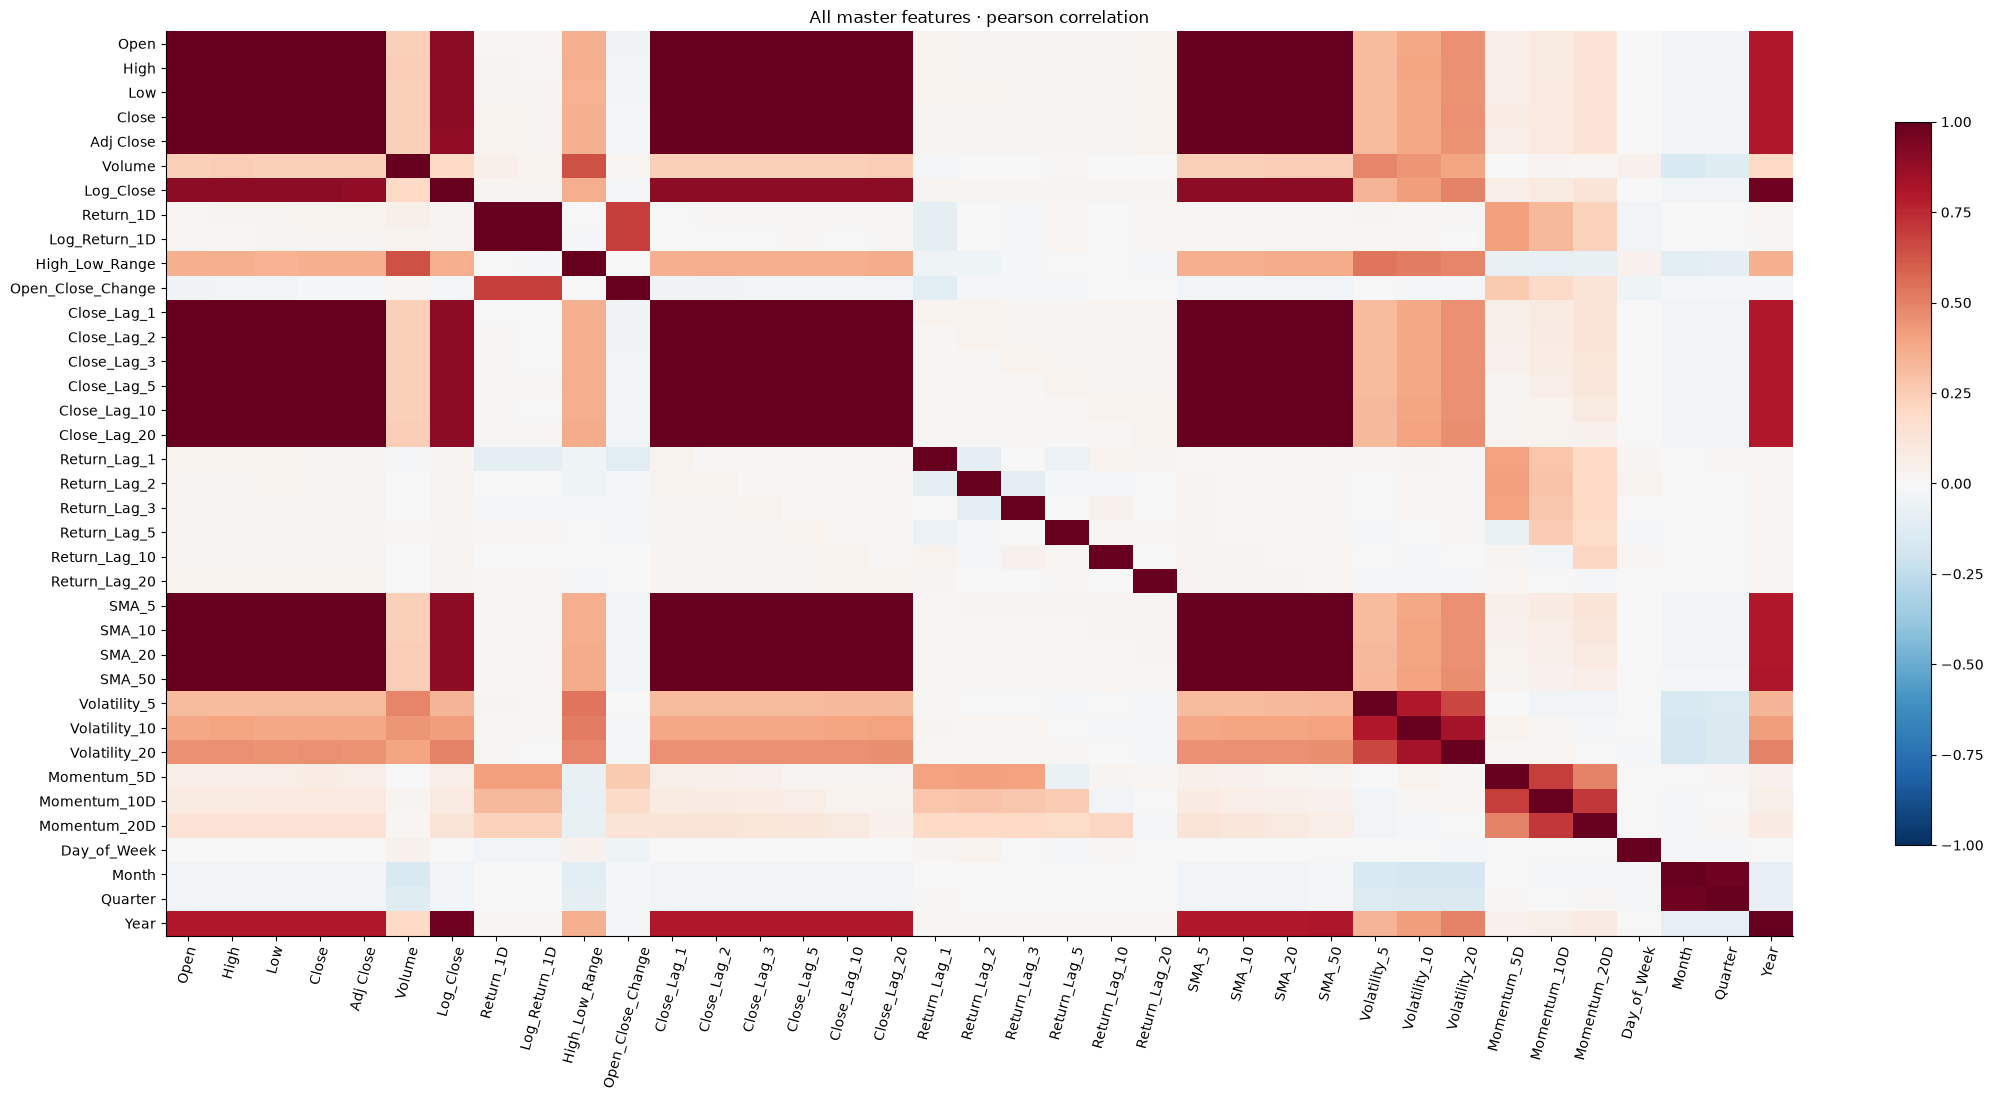

,Open,High,Low,Close,Adj Close,Volume,Log_Close,Return_1D,Log_Return_1D,High_Low_Range,Open_Close_Change,Close_Lag_1,Close_Lag_2,Close_Lag_3,Close_Lag_5,Close_Lag_10,Close_Lag_20,Return_Lag_1,Return_Lag_2,Return_Lag_3,Return_Lag_5,Return_Lag_10,Return_Lag_20,SMA_5,SMA_10,SMA_20,SMA_50,Volatility_5,Volatility_10,Volatility_20,Momentum_5D,Momentum_10D,Momentum_20D,Day_of_Week,Month,Quarter,Year
Open,1.000000,0.999915,0.999903,0.999800,0.999445,0.166241,0.999800,0.010233,0.010233,0.374353,-0.038801,0.999803,0.999431,0.999091,0.998476,0.997051,0.994247,0.022763,0.021941,0.020703,0.018895,0.019714,0.020025,0.999663,0.999165,0.998113,0.994981,0.337818,0.439968,0.520266,0.049899,0.074660,0.115845,-0.001220,-0.040833,-0.041388,0.977000
High,0.999915,1.000000,0.999896,0.999911,0.999570,0.168926,0.999911,0.016240,0.016240,0.378828,-0.030438,0.999719,0.999366,0.999039,0.998444,0.997039,0.994258,0.021959,0.021532,0.020615,0.018570,0.019656,0.020114,0.999633,0.999135,0.998093,0.994992,0.339851,0.441526,0.521537,0.051935,0.075918,0.116540,-0.001223,-0.041658,-0.042150,0.977184
Low,0.999903,0.999896,1.000000,0.999912,0.999550,0.163217,0.999912,0.016801,0.016801,0.368956,-0.030241,0.999702,0.999329,0.998977,0.998344,0.996889,0.994040,0.022754,0.022181,0.021014,0.018677,0.019841,0.020589,0.999587,0.999053,0.997957,0.994755,0.335613,0.437910,0.518469,0.053349,0.077466,0.118238,-0.001919,-0.040040,-0.040722,0.976984
Close,0.999800,0.999911,0.999912,1.000000,0.999638,0.165968,1.000000,0.022511,0.022511,0.373726,-0.022066,0.999601,0.999258,0.998914,0.998304,0.996872,0.994050,0.021724,0.021830,0.020803,0.018603,0.019735,0.020588,0.999544,0.999012,0.997933,0.994773,0.337701,0.439534,0.519854,0.055091,0.078518,0.118708,-0.001882,-0.041009,-0.041541,0.977117
Adj Close,0.999445,0.999570,0.999550,0.999638,1.000000,0.167715,0.999638,0.021922,0.021922,0.375051,-0.022085,0.999269,0.998948,0.998626,0.998044,0.996686,0.994010,0.021137,0.021230,0.020383,0.018155,0.019241,0.019871,0.999222,0.998729,0.997720,0.994793,0.339293,0.441855,0.522522,0.053704,0.076724,0.116319,-0.001960,-0.039261,-0.039405,0.979777


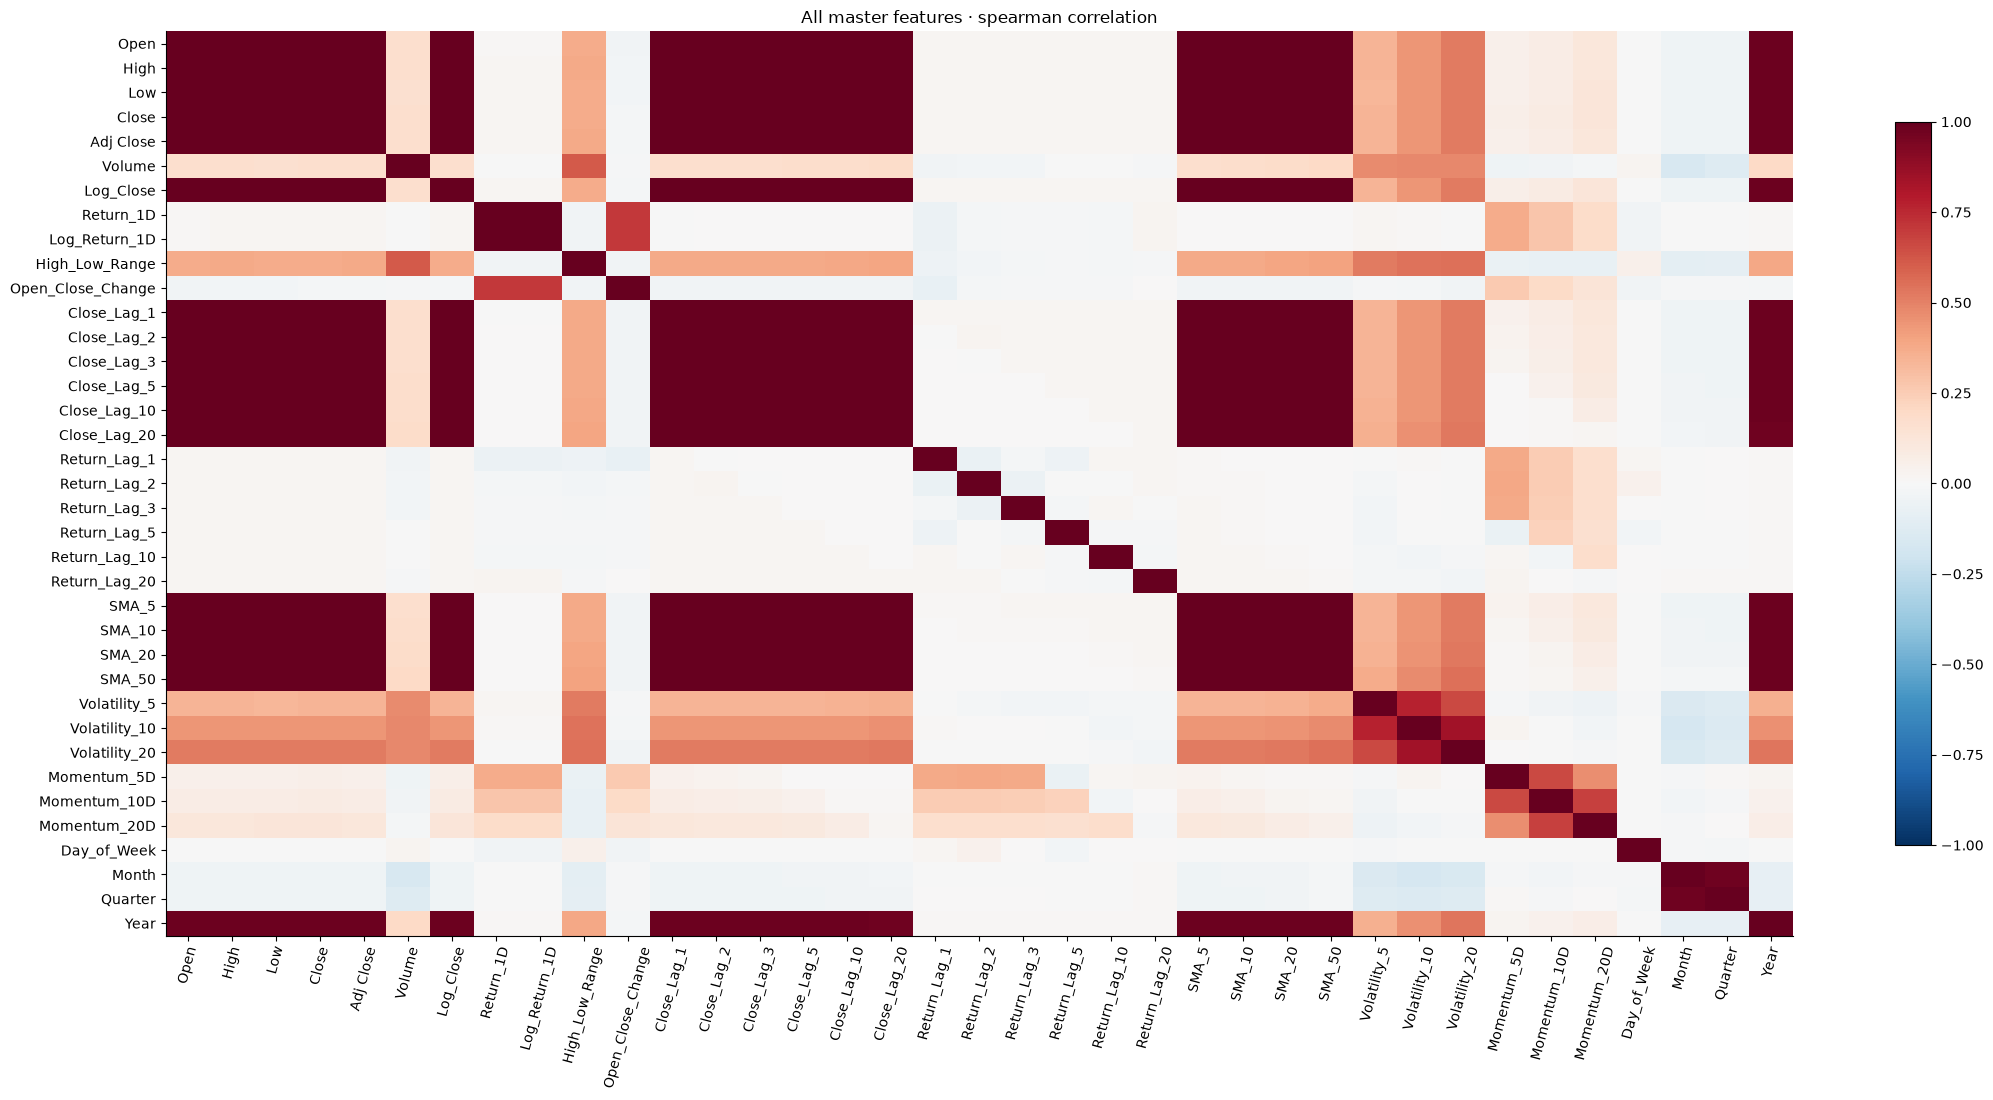

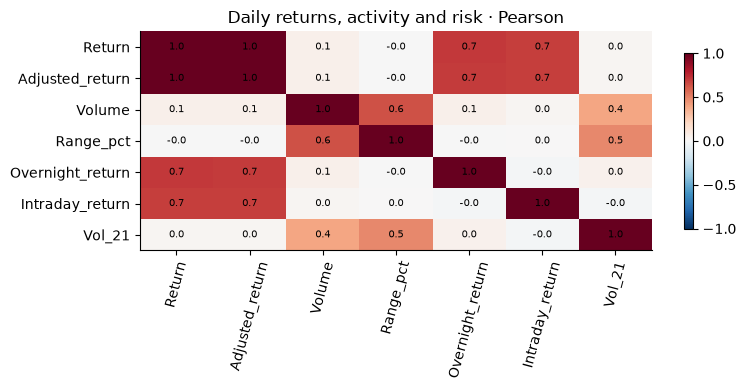

,Return,Volume,Annualized_daily_vol,Mean_daily_return
Return,1.000000,0.024937,0.020839,0.995589
Volume,0.024937,1.000000,0.588546,0.024497
Annualized_daily_vol,0.020839,0.588546,1.000000,0.042819
Mean_daily_return,0.995589,0.024497,0.042819,1.000000


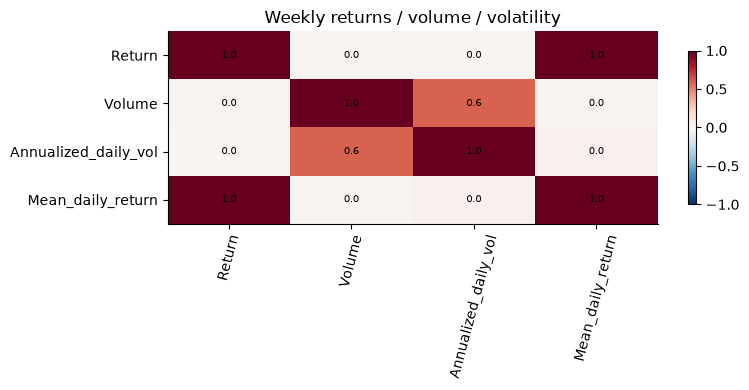

,Return,Volume,Annualized_daily_vol,Mean_daily_return
Return,1.000000,0.052781,0.089354,0.995736
Volume,0.052781,1.000000,0.696616,0.064963
Annualized_daily_vol,0.089354,0.696616,1.000000,0.110986
Mean_daily_return,0.995736,0.064963,0.110986,1.000000


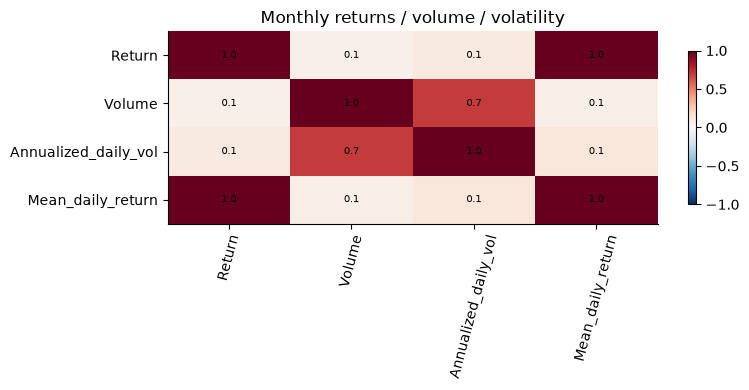

,Return,Volume,Annualized_daily_vol,Mean_daily_return
Return,1.000000,0.075180,0.306215,0.991591
Volume,0.075180,1.000000,0.642841,0.043313
Annualized_daily_vol,0.306215,0.642841,1.000000,0.254059
Mean_daily_return,0.991591,0.043313,0.254059,1.000000


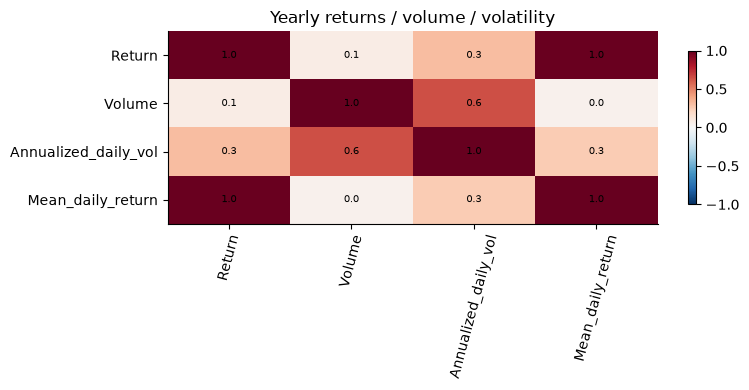

,Feature,Horizon_sessions,Pairs,Pearson,Spearman
0,Return,1,3769,-0.089625,-0.062350
1,Volume,1,3770,0.000701,-0.008030
2,Range_pct,1,3770,0.010541,-0.016409
3,Vol_21,1,3749,0.008592,0.000324
4,Momentum_20D,1,3750,-0.015226,-0.024096
5,Return,5,3765,-0.066900,-0.068619
6,Volume,5,3766,-0.009183,-0.019269
7,Range_pct,5,3766,0.028788,0.018127
8,Vol_21,5,3745,0.016888,0.002847
9,Momentum_20D,5,3746,0.000534,0.000850


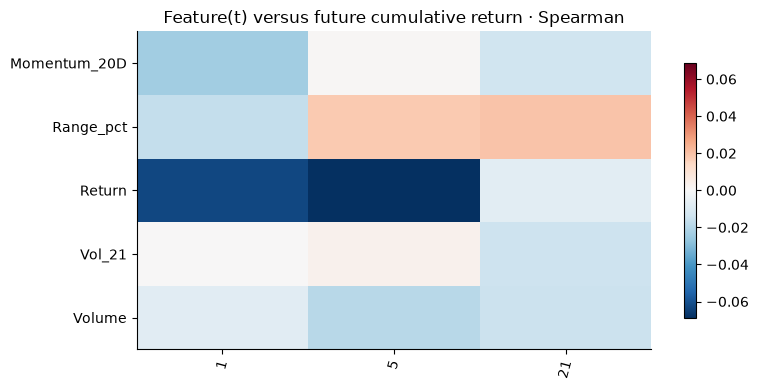

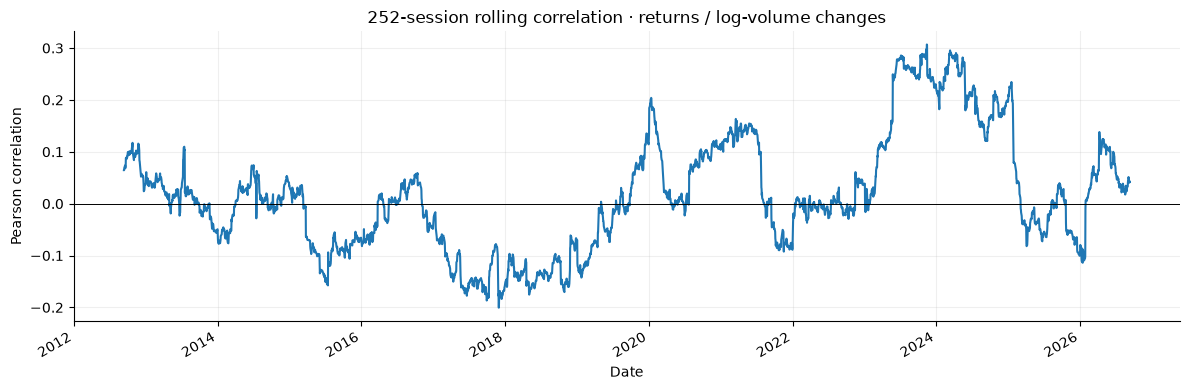

In [9]:
for method in ["pearson","spearman"]:
    corr=df.corr(method=method)
    show_table(f"master_{method}_correlation",corr,5)
    heatmap(corr,f"All master features · {method} correlation")
cols=["Return","Adjusted_return","Volume","Range_pct","Overnight_return","Intraday_return","Vol_21"]
heatmap(daily[cols].corr(),"Daily returns, activity and risk · Pearson",True)
for name,t in period_tables.items():
    corr=t.loc[t.Return_usable,["Return","Volume","Annualized_daily_vol","Mean_daily_return"]].corr()
    show_table(f"{name}_correlation",corr)
    heatmap(corr,f"{name} returns / volume / volatility",True)
lagged=[]
for h in [1,5,21]:
    future=daily.Close.shift(-h)/daily.Close-1
    for col in ["Return","Volume","Range_pct","Vol_21","Momentum_20D"]:
        pair=pd.concat([daily[col],future.rename("Future_return")],axis=1).dropna()
        lagged.append({"Feature":col,"Horizon_sessions":h,"Pairs":len(pair),
            "Pearson":pair.iloc[:,0].corr(pair.iloc[:,1]),
            "Spearman":pair.iloc[:,0].corr(pair.iloc[:,1],method="spearman")})
show_table("future_return_correlations",pd.DataFrame(lagged),20)
heatmap(pd.DataFrame(lagged).pivot(index="Feature",columns="Horizon_sessions",values="Spearman"),"Feature(t) versus future cumulative return · Spearman")
rolling=daily.Return.rolling(252).corr(np.log1p(daily.Volume.clip(lower=0)).diff())
rolling.plot(title="252-session rolling correlation · returns / log-volume changes")
plt.axhline(0,color="black",lw=.7); plt.ylabel("Pearson correlation"); plt.tight_layout(); plt.show()

## 10 · ACF, PACF and volatility clustering
Inspect log prices, returns and squared returns. Price persistence may be nonstationarity; squared-return dependence indicates clustering in magnitude rather than direction. Daily lags represent observed trading rows; calendar gaps are reported. Aggregate diagnostics use the longest contiguous usable run and do not compress missing periods. Annual samples have low power.

ACF bands are approximate. Ljung–Box tests screen joint serial dependence, with BH correction across reported tests. These exploratory results are not direct instructions to select ARIMA orders.

Ljung_Box_tests: 20 rows; complete table retained in TABLES
Calendar missing sessions: 0 unexpected dates: 0


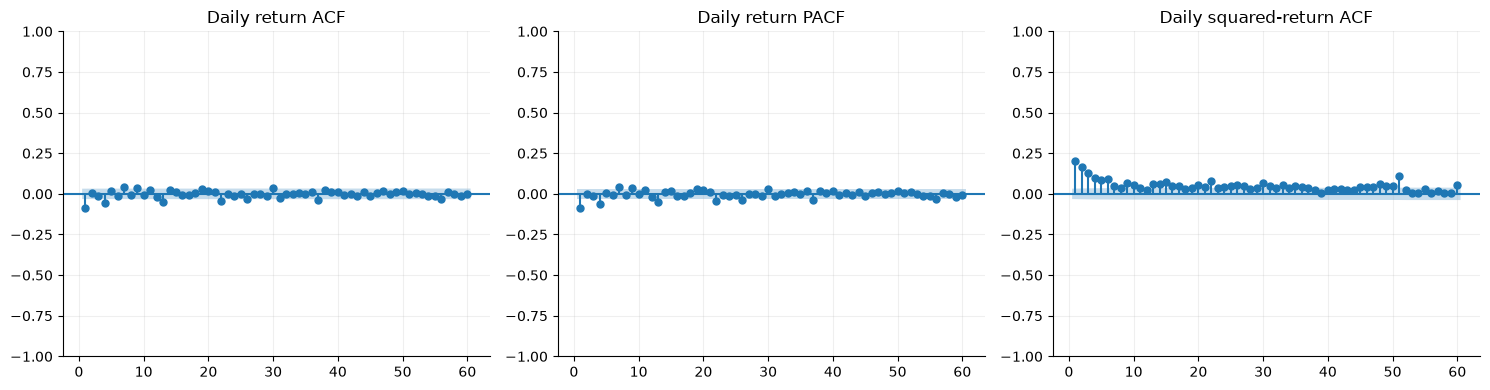

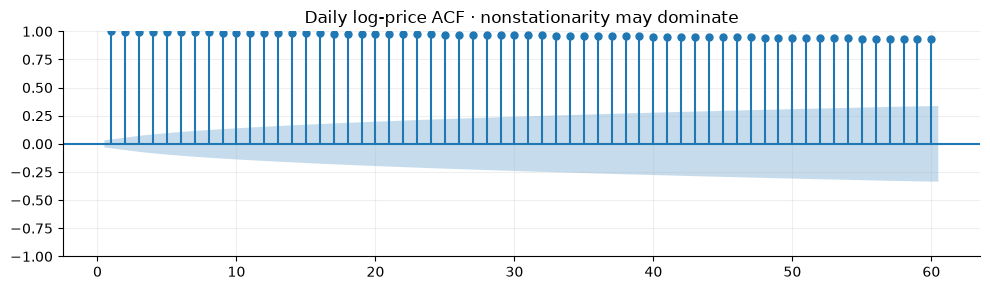

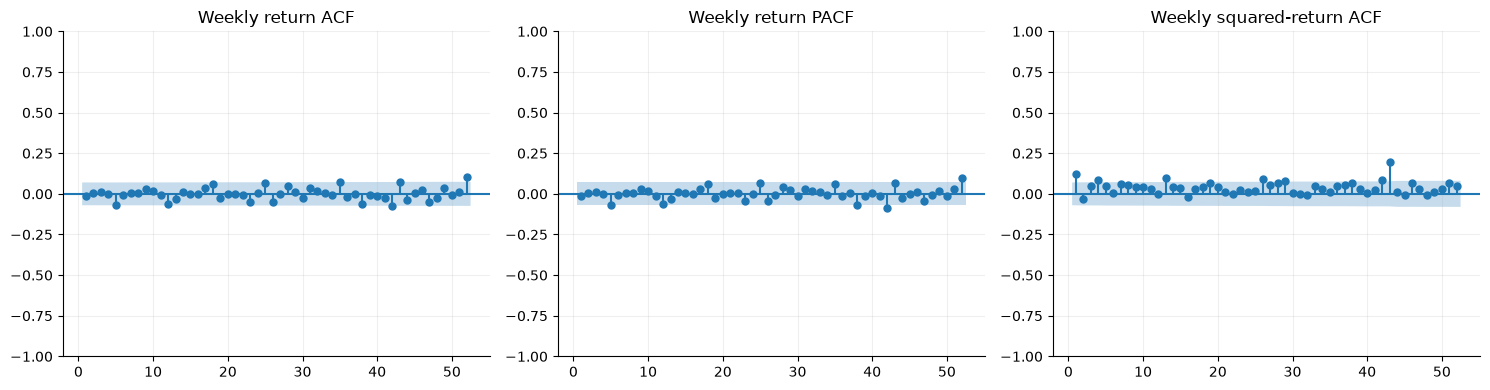

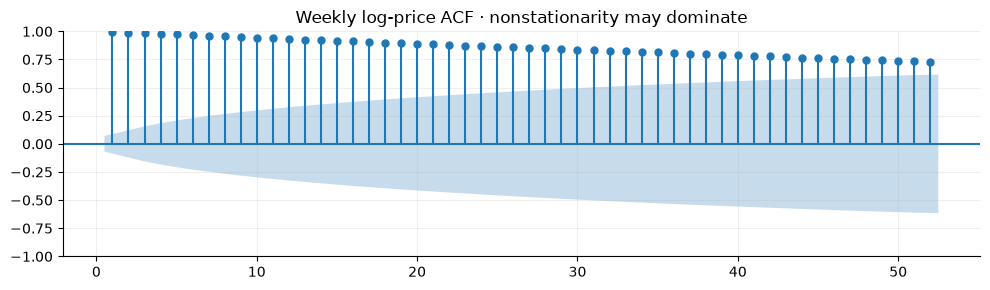

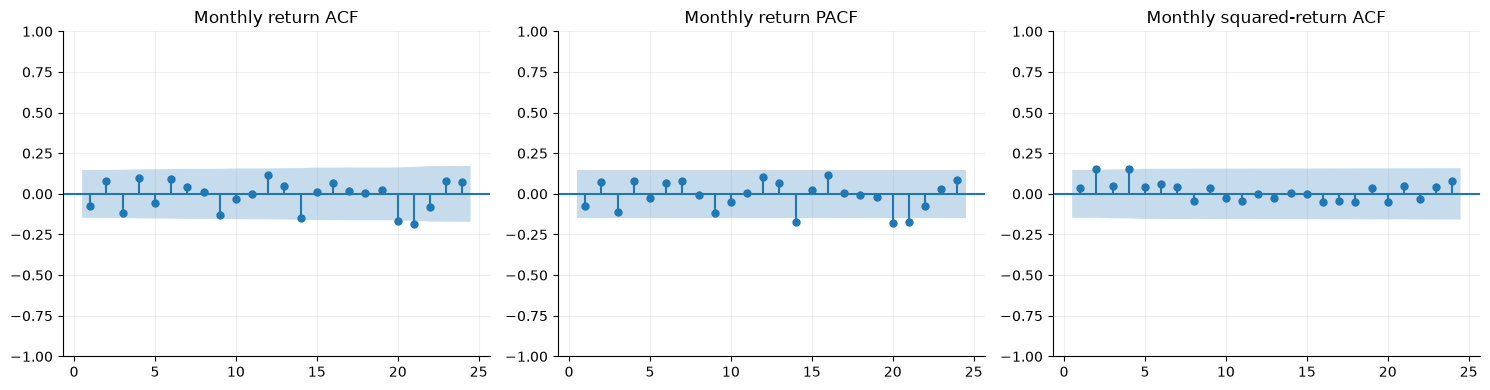

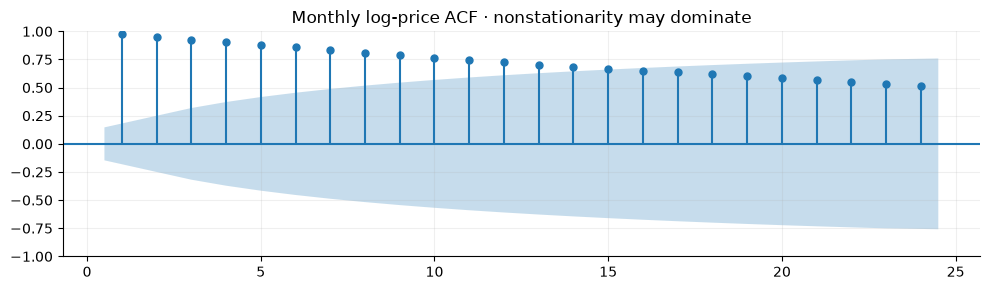

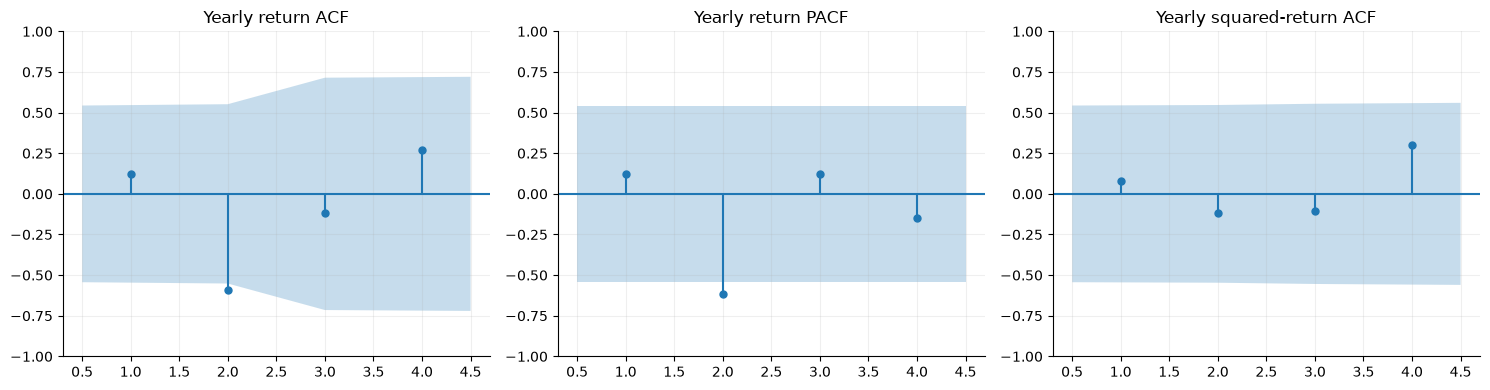

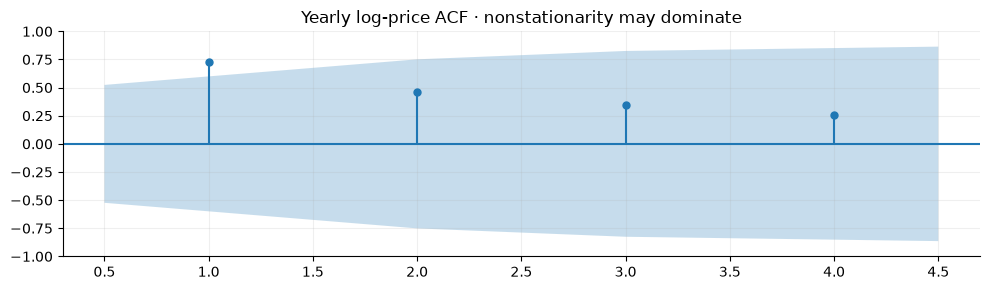

,lb_stat,lb_pvalue,Frequency,Series,Lag,N,BH_adjusted_p
0,45.043149,1.421865e-08,Daily,Return,5,3770,5.687458e-08
1,57.723109,9.747012e-09,Daily,Return,10,3770,4.873506e-08
2,117.345633,1.381478e-05,Daily,Return,60,3770,3.947081e-05
3,378.133516,1.527840e-79,Daily,Squared_return,5,3770,1.018560e-78
4,453.765627,3.286485e-91,Daily,Squared_return,10,3770,3.286485e-90
5,822.526961,1.928221e-134,Daily,Squared_return,60,3770,3.856442e-133
6,3.732267,5.885696e-01,Weekly,Return,5,781,6.924348e-01
7,4.664736,9.124202e-01,Weekly,Return,10,781,9.124202e-01
8,55.829856,3.329630e-01,Weekly,Return,52,781,4.371644e-01
9,22.266864,4.658320e-04,Weekly,Squared_return,5,781,1.164580e-03


In [10]:
def longest_run(s):
    valid=s.notna().to_numpy()
    starts=np.flatnonzero(valid & ~np.r_[False,valid[:-1]])
    stops=np.flatnonzero(valid & ~np.r_[valid[1:],False])+1
    if not len(starts): return s.iloc[:0]
    k=np.argmax(stops-starts); return s.iloc[starts[k]:stops[k]]
serial={"Daily":daily[["Close","Return"]]}
for name,t in period_tables.items():
    serial[name]=pd.DataFrame({"Close":t.Close.where(t.Complete),"Return":t.Return.where(t.Return_usable)})
ljung=[]
for name,t in serial.items():
    s=longest_run(t.Return)
    if len(s)<10: print(name,"too short for serial diagnostics"); continue
    lag=min({"Daily":60,"Weekly":52,"Monthly":24,"Yearly":4}[name],len(s)//2-1)
    fig,axes=plt.subplots(1,3,figsize=(15,4))
    plot_acf(s,lags=lag,zero=False,ax=axes[0]); axes[0].set_title(f"{name} return ACF")
    plot_pacf(s,lags=lag,zero=False,method="ywm",ax=axes[1]); axes[1].set_title(f"{name} return PACF")
    plot_acf(s**2,lags=lag,zero=False,ax=axes[2]); axes[2].set_title(f"{name} squared-return ACF")
    plt.tight_layout(); plt.show()
    price=longest_run(t.Close)
    fig,ax=plt.subplots(figsize=(10,3)); plot_acf(np.log(price),lags=min(lag,len(price)-1),zero=False,ax=ax)
    ax.set_title(f"{name} log-price ACF · nonstationarity may dominate"); plt.tight_layout(); plt.show()
    lags=sorted(set([min(5,lag),min(10,lag),lag]))
    for label,values in [("Return",s),("Squared_return",s**2)]:
        result=acorr_ljungbox(values,lags=lags,return_df=True)
        result["Frequency"]=name; result["Series"]=label; result["Lag"]=result.index; result["N"]=len(s)
        ljung.append(result.reset_index(drop=True))
ljung=pd.concat(ljung,ignore_index=True)
ljung["BH_adjusted_p"]=multipletests(ljung.lb_pvalue,method="fdr_bh")[1]
show_table("Ljung_Box_tests",ljung,40)
print("Calendar missing sessions:",int(calendar.Missing_session.sum()),"unexpected dates:",int(calendar.Unexpected_record.sum()))

## 11 · Stationarity diagnostics
ADF's null is a unit root; KPSS's null is stationarity. Test log price around a deterministic trend (`ct`) and returns around a constant (`c`). Structural breaks and limited samples affect both tests. Fewer than 30 observations are skipped. Warnings, including bounded KPSS p-values, are preserved instead of treating those p-values as exact.

In [11]:
stationarity=[]
for name,t in serial.items():
    for label,s,reg in [("Log_price",np.log(longest_run(t.Close)),"ct"),("Return",longest_run(t.Return),"c")]:
        if len(s)<30:
            stationarity.append({"Frequency":name,"Series":label,"N":len(s),"Status":"Skipped: fewer than 30 observations"}); continue
        with warnings.catch_warnings(record=True) as captured:
            warnings.simplefilter("always")
            try:
                a=adfuller(s,regression=reg,autolag="AIC"); k=kpss(s,regression=reg,nlags="auto")
                row={"Frequency":name,"Series":label,"N":len(s),"Regression":reg,
                    "ADF_stat":a[0],"ADF_p":a[1],"ADF_lags":a[2],"KPSS_stat":k[0],"KPSS_p":k[1],"KPSS_lags":k[2],"Status":"computed"}
            except (ValueError,np.linalg.LinAlgError) as exc:
                row={"Frequency":name,"Series":label,"N":len(s),"Status":str(exc)}
        row["Warnings"]=" | ".join(dict.fromkeys(str(w.message) for w in captured))
        stationarity.append(row)
show_table("stationarity_tests",pd.DataFrame(stationarity),30)

stationarity_tests: 8 rows; complete table retained in TABLES


,Frequency,Series,N,Regression,ADF_stat,ADF_p,ADF_lags,KPSS_stat,KPSS_p,KPSS_lags,Status,Warnings
0,Daily,Log_price,3771,ct,-1.852216,6.790529e-01,13.0,0.596808,0.010000,38.0,computed,"adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning. | The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned. | kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning."
1,Daily,Return,3770,c,-17.468318,4.557331e-30,12.0,0.193633,0.100000,17.0,computed,"adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning. | The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned. | kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning."
2,Weekly,Log_price,782,ct,-1.961802,6.220774e-01,0.0,0.286733,0.010000,17.0,computed,"adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning. | The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned. | kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning."
3,Weekly,Return,781,c,-28.362744,0.000000e+00,0.0,0.180737,0.100000,1.0,computed,"adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning. | The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned. | kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning."
4,Monthly,Log_price,179,ct,-1.898503,6.554443e-01,0.0,0.154744,0.042713,8.0

## 12 · Computed summary and optional exports
The summary below is computed for the chosen data window. Review anomaly dates against primary historical sources before attributing a cause. Calendar results depend on the recorded package version. Full tables are accessible through `TABLES`; CSV exports are optional and disabled by default.

In [12]:
summary=pd.DataFrame([
    ("Observed records",len(daily)),("Scheduled sessions",int(calendar.Expected_session.sum())),
    ("Regular weekday holidays",int(calendar.Regular_holiday.sum())),
    ("Exceptional weekday closures",int(calendar.Exceptional_closure.sum())),
    ("Early-close sessions",int(calendar.Early_close.sum())),
    ("Missing scheduled sessions",int(calendar.Missing_session.sum())),
    ("Unexpected records",int(calendar.Unexpected_record.sum())),
    ("Worst close-price drawdown (%)",float(daily.Drawdown.min()*100)),
    ("Daily return skew",float(daily.Return.skew())),
    ("Daily return excess kurtosis",float(daily.Return.kurt())),
    ("Any-anomaly flagged dates",int(anomalies.Any_flag.sum()))],columns=["Measure","Value"])
show_table("summary",summary,20)
print("Largest daily gain:",daily.Return.idxmax().date(),f"{daily.Return.max():.2%}")
print("Largest daily loss:",daily.Return.idxmin().date(),f"{daily.Return.min():.2%}")
for name,t in period_tables.items():
    s=t.loc[t.Return_usable,"Return"]
    if len(s): print(f"{name}: best {s.idxmax()} ({s.max():.2%}); worst {s.idxmin()} ({s.min():.2%})")
print("Seasonality screens below 5% after BH correction:",screens.loc[screens.BH_adjusted_p<.05,"Grouping"].tolist())
print("Apply the dependence and multiple-comparison caveats above; these are descriptive results.")
if EXPORT_TABLES:
    OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
    for name,t in TABLES.items(): t.to_csv(OUTPUT_DIR/f"{name}.csv")
    calendar.to_csv(OUTPUT_DIR/"daily_calendar_audit.csv")
    metadata={"source":str(DATA_PATH),"sha256":hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
        "start":str(start.date()),"end":str(end.date()),"calendar":CALENDAR_NAME,"versions":VERSIONS,
        "analysis_end":ANALYSIS_END,"week_definition":"Monday-Sunday","scope":"retrospective descriptive EDA"}
    (OUTPUT_DIR/"metadata.json").write_text(json.dumps(metadata,indent=2),encoding="utf-8")
    print("Exported",len(TABLES),"tables to",OUTPUT_DIR)
else: print("Exports disabled; complete tables remain in TABLES.")

summary: 11 rows; complete table retained in TABLES
Largest daily gain: 2020-07-27 12.65%
Largest daily loss: 2020-03-16 -14.03%
Weekly: best 2022-11-07/2022-11-13 (18.17%); worst 2020-03-16/2020-03-22 (-14.74%)
Monthly: best 2020-07 (38.96%); worst 2022-09 (-17.74%)
Yearly: best 2024 (89.89%); worst 2022 (-38.08%)
Seasonality screens below 5% after BH correction: []
Apply the dependence and multiple-comparison caveats above; these are descriptive results.
Exports disabled; complete tables remain in TABLES.


,Measure,Value
0,Observed records,3771.000000
1,Scheduled sessions,3771.000000
2,Regular weekday holidays,139.000000
3,Exceptional weekday closures,4.000000
4,Early-close sessions,33.000000
5,Missing scheduled sessions,0.000000
6,Unexpected records,0.000000
7,Worst close-price drawdown (%),-57.144890
8,Daily return skew,0.190449
9,Daily return excess kurtosis,3.974371


## 13 · Seasonal indices: trend-adjusted monthly pattern and weekday effects

The **monthly seasonal index** uses the classical ratio-to-centered-moving-average method. Average two adjacent 12-month means to obtain a centered trend; divide each complete month-end close by that trend; average ratios by calendar month; normalize the 12 factors to mean **100**. An index of 103 means about 3% above the estimated trend, **not** an expected 3% monthly return. The first and last six complete months lack a centered trend and are excluded from estimation.

The early/late comparison estimates each half independently. A changed sign around 100 suggests instability. Weekday returns can be negative or close to zero, so their effect is expressed as **basis points above/below the pooled daily mean**, not a multiplicative return ratio.

These full-history indices use future data to estimate the trend. They are descriptive EDA, not inputs available to a historical trader. Read them with section 7's adjusted calendar tests and STL strength. Run sections 1–5 first. The helper `Data/seasonal_index_analysis.py` contains the reusable functions; existing loaders and `ANALYSIS_END` remain in force.


Early/late comparison: {'Early_period': '2011-10 to 2019-02', 'Late_period': '2019-03 to 2026-08'}
Monthly index mean: 100.0
Valid detrended monthly observations: 167
Interpretation: 100 = trend baseline; index minus 100 is a relative price-level effect, not a return forecast.


,Count,Mean_ratio,Std_ratio,Seasonal_index,Deviation_from_100,Early_index,Late_index,Same_side_of_100
Month,,,,,,,,
1,14,102.803407,8.266028,103.529720,3.529720,100.312160,107.372605,1.0
2,14,101.891432,6.028810,102.611301,2.611301,102.011843,103.549872,1.0
3,13,100.190103,8.373730,100.897953,0.897953,103.130355,98.016184,0.0
4,14,98.230214,8.720246,98.924216,-1.075784,101.763831,93.615749,0.0
5,14,97.941572,8.348485,98.633535,-1.366465,100.174251,97.518974,0.0
6,14,98.101813,8.035882,98.794908,-1.205092,98.385404,100.226695,0.0
7,14,99.495677,4.330194,100.198620,0.198620,97.657169,103.604512,0.0
8,14,97.487493,5.461225,98.176249,-1.823751,97.836165,99.102702,1.0
9,14,97.020651,7.844441,97.706108,-2.293892,97.365755,95.650218,1.0


,Close,Centered_12M_trend,Ratio_to_trend,Seasonal_index,Deseasonalized_close
Date,,,,,
2011-10,12.62,NaN,NaN,99.153394,12.727754
2011-11,12.92,NaN,NaN,100.977287,12.794957
2011-12,12.91,NaN,NaN,100.396709,12.858987
2012-01,14.08,NaN,NaN,103.529720,13.599959
2012-02,14.52,NaN,NaN,102.611301,14.150489
2012-03,15.28,NaN,NaN,100.897953,15.144014
2012-04,15.58,14.310833,108.868573,98.924216,15.749430
2012-05,13.73,14.628750,93.856273,98.633535,13.920214
2012-06,13.96,14.987083,93.146877,98.794908,14.130283


,Count,Mean_return,Std_return,Excess_return_bps
Weekday,,,,
Monday,706,0.000891,0.020653,-2.599301
Tuesday,776,0.001969,0.018872,8.180017
Wednesday,773,0.002287,0.019670,11.360878
Thursday,759,0.001275,0.022403,1.234644
Friday,756,-0.000731,0.018666,-18.824921


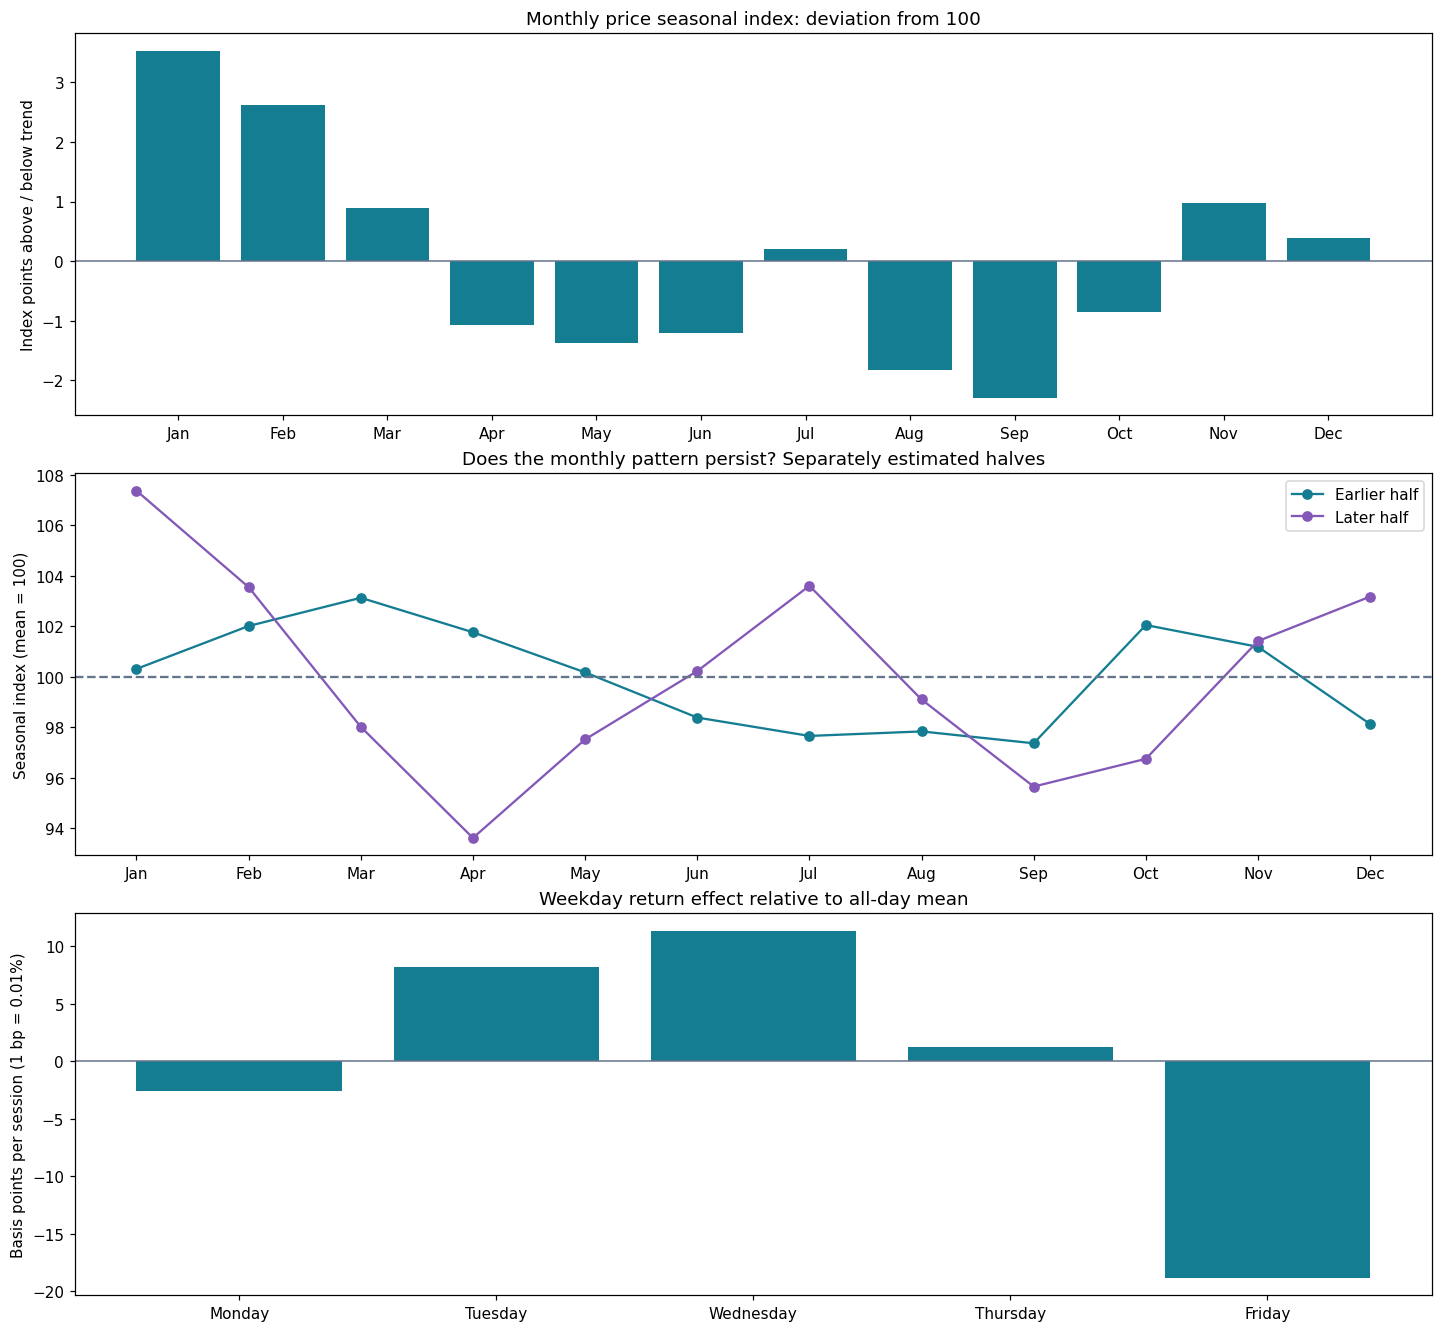

In [ ]:
import importlib.util
_helper = DATA_PATH.parent / "seasonal_index_analysis.py"
_spec = importlib.util.spec_from_file_location("tsmc_seasonal", _helper)
_seasonal = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_seasonal)
_complete_close = period_tables["Monthly"].loc[period_tables["Monthly"].Complete, "Close"]
seasonal_index, seasonal_detail, weekday_effect, seasonal_metadata = _seasonal.seasonal_analysis(daily, _complete_close)
show_table("monthly_seasonal_index", seasonal_index, 12)
show_table("seasonal_index_detail", seasonal_detail, 12)
show_table("weekday_return_effect", weekday_effect, 5)
print("Early/late comparison:", seasonal_metadata)
print("Monthly index mean:", seasonal_index.Seasonal_index.mean())
print("Valid detrended monthly observations:", int(seasonal_index.Count.sum()))
print("Interpretation: 100 = trend baseline; index minus 100 is a relative price-level effect, not a return forecast.")
_seasonal.plot_seasonal_indices(seasonal_index, weekday_effect)
plt.show()
if EXPORT_TABLES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    for _name in ["monthly_seasonal_index", "seasonal_index_detail", "weekday_return_effect"]:
        TABLES[_name].to_csv(OUTPUT_DIR / (_name + ".csv"))
